# Лабораторна робота 2: багатокласова логістична регресія (NumPy) та федеративне навчання (FedAvg)


In [1]:
# ==============================================================================
# 0. СИСТЕМНІ НАЛАШТУВАННЯ ТА ІМПОРТ БІБЛІОТЕК
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

print(f"Середовище налаштовано! SEED = {SEED}")

Середовище налаштовано! SEED = 42


In [2]:
# ==============================================================================
# 1. ЗАВАНТАЖЕННЯ ТА ДОСЛІДЖЕННЯ ДАТАСЕТУ
# ==============================================================================
filename = "Dry_Bean_Dataset.xlsx"

if not os.path.exists(filename):
    raise FileNotFoundError(f"Файл '{filename}' не знайдено у поточній директорії: {os.getcwd()}")

# Читаємо датасет за допомогою openpyxl
df = pd.read_excel(filename, sheet_name="Dry_Beans_Dataset", engine="openpyxl")
print(f"Початкова розмірність: {df.shape[0]} рядків, {df.shape[1]} стовпців")
print(f"Кількість явних пропусків: {df.isnull().sum().sum()}")

print("\n--- Структура датасету та типи ознак ---")
df.info()
print(f"\nОзнак: {df.shape[1]-1} (усі числові), цільова змінна: 'Class', унікальних класів: {df['Class'].nunique()}")

# Перевірка та видалення дублікатів (запобігання витоку між підвибірками)
n_duplicates = df.duplicated().sum()
print(f"Кількість дублікатів: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Розмірність після видалення дублікатів: {df.shape}")

display(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

Початкова розмірність: 13611 рядків, 17 стовпців
Кількість явних пропусків: 0

--- Структура датасету та типи ознак ---
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64


,mean,std,min,50%,max
Area,53048.460385,29392.438324,20420.000000,44580.000000,254616.000000
Perimeter,854.993406,214.722684,524.736000,793.896000,1985.370000
MajorAxisLength,319.895602,85.809260,183.601165,296.404589,738.860153
MinorAxisLength,202.365321,45.051632,122.512653,192.491117,460.198497
AspectRation,1.581075,0.245245,1.024868,1.549860,2.430306
Eccentricity,0.750315,0.091858,0.218951,0.763997,0.911423
ConvexArea,53767.986709,29844.248525,20684.000000,45122.000000,263261.000000
EquivDiameter,253.034094,59.307709,161.243764,238.245711,569.374358
Extent,0.749829,0.048939,0.555315,0.759903,0.866195
Solidity,0.987152,0.004650,0.919246,0.988288,0.994677


Усі 16 ознак числові, пропусків немає. Дублікатів 68 (0.5%) — їх видалили до розбиття, щоб однакові рядки не потрапили і в навчання, і в тест. Масштаби ознак дуже різні (Area ≈ 50 000, Solidity ≈ 0.99), тому далі потрібна стандартизація. Категоріальних ознак немає, тож кодувати нічого.

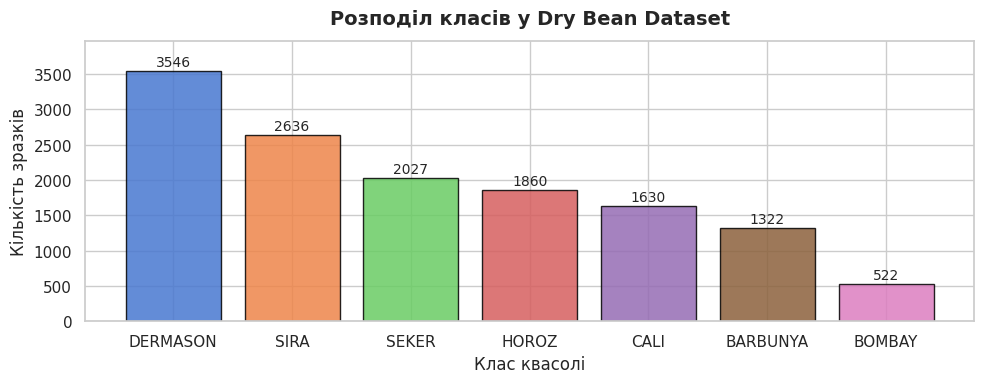

In [3]:
plt.figure(figsize=(10, 4))
class_counts = df['Class'].value_counts()
colors = sns.color_palette("muted", len(class_counts))
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 30, f'{int(yval)}', ha='center', va='bottom', fontsize=10)

plt.title("Розподіл класів у Dry Bean Dataset", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Клас квасолі", fontsize=12)
plt.ylabel("Кількість зразків", fontsize=12)
plt.ylim(0, max(class_counts.values) * 1.12)
plt.tight_layout()
plt.show()

Класи нерівні: DERMASON ≈ 26%, а BOMBAY лише ≈ 3.9%. Через це дивимось не тільки на accuracy, а й на macro-F1 та balanced accuracy, а розбиття робимо стратифіковане (з однаковими частками класів).

## 2. Розбиття вибірки (до масштабування, відбору ознак і будь-яких «навчуваних» перетворень)

Спочатку формуємо три множини: **Global Test (15%)**, **Global Validation (15%)**, **FL Train Pool (70%)** — усі стратифіковані за класами. Кореляційний аналіз і відбір ознак виконуються **вже після розбиття й лише на Train Pool** (у попередній версії ноутбука кореляції рахувались на всьому датасеті, що суперечило вимозі «без використання тестової вибірки»).

In [4]:
# ==============================================================================
# 2. СТРАТИФІКОВАНЕ РОЗБИТТЯ (ДО SCALING)
# ==============================================================================
feature_names = list(df.drop(columns=['Class']).columns)
X_raw = df.drop(columns=['Class']).values
y_raw = df['Class'].values

# Кодування класів у числові індекси 0..C-1
classes, y_indices = np.unique(y_raw, return_inverse=True)
num_classes = len(classes)
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

# Стратифікований поділ: 70% Train Pool, 15% Validation, 15% Test
X_train_pool_raw, X_temp_raw, y_train_pool_idx, y_temp_idx = train_test_split(
    X_raw, y_indices, test_size=0.30, random_state=SEED, stratify=y_indices
)

X_val_raw, X_test_raw, y_val_idx, y_test_idx = train_test_split(
    X_temp_raw, y_temp_idx, test_size=0.50, random_state=SEED, stratify=y_temp_idx
)

# One-hot кодування
def to_one_hot(indices, n_cls):
    return np.eye(n_cls)[indices]

Y_train_pool = to_one_hot(y_train_pool_idx, num_classes)
Y_val = to_one_hot(y_val_idx, num_classes)
Y_test = to_one_hot(y_test_idx, num_classes)

# Перевірка стратифікації
split_summary = pd.DataFrame({
    'Train Pool': pd.Series(y_train_pool_idx).value_counts().sort_index(),
    'Validation': pd.Series(y_val_idx).value_counts().sort_index(),
    'Test': pd.Series(y_test_idx).value_counts().sort_index(),
}, index=range(num_classes))

split_summary['Class Name'] = [classes[i] for i in split_summary.index]
split_summary['Train %'] = (split_summary['Train Pool'] / len(y_train_pool_idx) * 100).round(2)
split_summary['Val %'] = (split_summary['Validation'] / len(y_val_idx) * 100).round(2)
split_summary['Test %'] = (split_summary['Test'] / len(y_test_idx) * 100).round(2)

print("--- Зведена таблиця стратифікації ---")
display(split_summary[['Class Name', 'Train Pool', 'Train %', 'Validation', 'Val %', 'Test', 'Test %']])
print(f"Розміри: Train Pool = {len(X_train_pool_raw)}, Val = {len(X_val_raw)}, Test = {len(X_test_raw)}")

--- Зведена таблиця стратифікації ---


,Class Name,Train Pool,Train %,Validation,Val %,Test,Test %
0,BARBUNYA,925,9.76,199,9.80,198,9.74
1,BOMBAY,366,3.86,78,3.84,78,3.84
2,CALI,1141,12.04,244,12.01,245,12.06
3,DERMASON,2482,26.18,532,26.19,532,26.18
4,HOROZ,1302,13.73,279,13.74,279,13.73
5,SEKER,1419,14.97,304,14.97,304,14.96
6,SIRA,1845,19.46,395,19.45,396,19.49


Розміри: Train Pool = 9480, Val = 2031, Test = 2032


Вийшло Train Pool 9 480 / Validation 2 031 / Test 2 032 (70 / 15 / 15). Частки класів у всіх трьох множинах майже однакові (різниця менша за 0.1 п.п.), навіть для рідкісного BOMBAY. Розбиваємо до масштабування, бо інакше середнє й σ порахувались би і по тестових даних — це Data Leakage, і оцінка на тесті стала б завищеною.

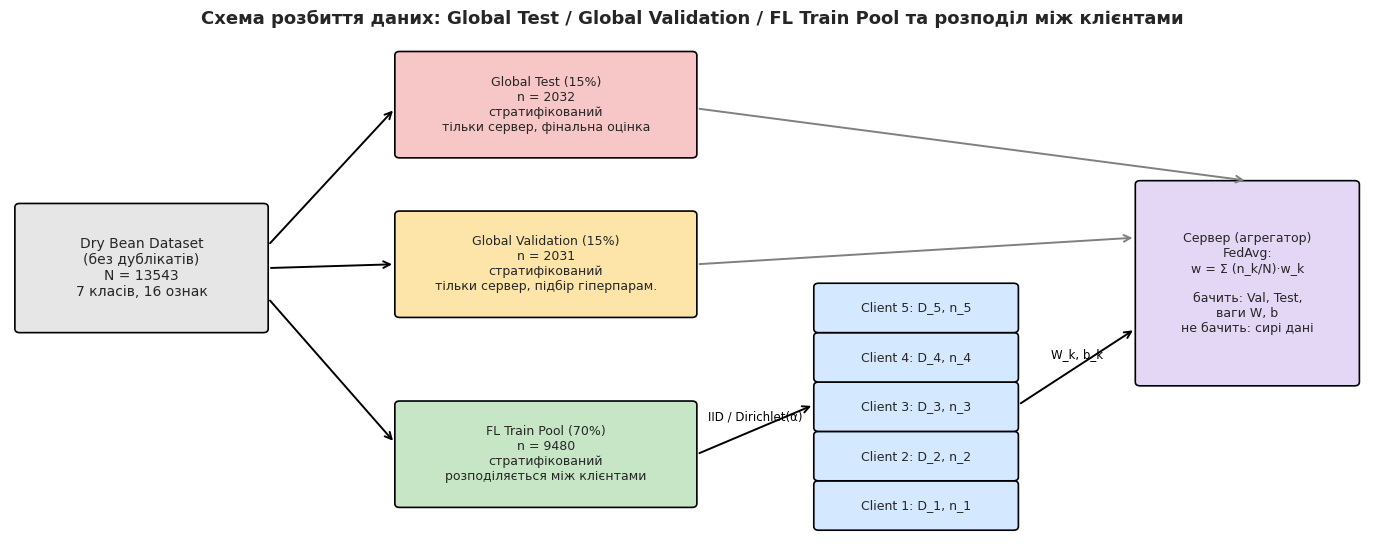

In [5]:

# ==============================================================================
# 2.1 СХЕМА РОЗБИТТЯ ДАНИХ ТА РОЗПОДІЛУ МІЖ СЕРВЕРОМ І КЛІЄНТАМИ
# ==============================================================================
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5.6))
ax.axis('off'); ax.set_xlim(0, 14); ax.set_ylim(-0.4, 6.2)

def box(x, y, w, h, text, color, fs=10):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", fc=color, ec='black', lw=1.2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs)

def arrow(p1, p2, text=None, color='black'):
    ax.annotate('', xy=p2, xytext=p1, arrowprops=dict(arrowstyle='->', lw=1.4, color=color))
    if text:
        ax.text((p1[0]+p2[0])/2, (p1[1]+p2[1])/2 + 0.12, text, ha='center', fontsize=8.5, color=color)

N_all = len(X_raw)
box(0.1, 2.3, 2.5, 1.6, f"Dry Bean Dataset\n(без дублікатів)\nN = {N_all}\n7 класів, 16 ознак", '#e6e6e6')
box(4.0, 4.6, 3.0, 1.3, f"Global Test (15%)\nn = {len(X_test_raw)}\nстратифікований\nтільки сервер, фінальна оцінка", '#f7c6c6', 9)
box(4.0, 2.5, 3.0, 1.3, f"Global Validation (15%)\nn = {len(X_val_raw)}\nстратифікований\nтільки сервер, підбір гіперпарам.", '#fde4a8', 9)
box(4.0, 0.0, 3.0, 1.3, f"FL Train Pool (70%)\nn = {len(X_train_pool_raw)}\nстратифікований\nрозподіляється між клієнтами", '#c6e6c6', 9)
arrow((2.65, 3.4), (3.95, 5.2)); arrow((2.65, 3.1), (3.95, 3.15)); arrow((2.65, 2.7), (3.95, 0.8))
for k in range(5):
    box(8.3, -0.3 + k*0.65, 2.0, 0.55, f"Client {k+1}: D_{k+1}, n_{k+1}", '#d4e8ff', 9)
arrow((7.05, 0.65), (8.25, 1.3), 'IID / Dirichlet(α)')
box(11.6, 1.6, 2.2, 2.6, "Сервер (агрегатор)\nFedAvg:\nw = Σ (n_k/N)·w_k\n\nбачить: Val, Test,\nваги W, b\nне бачить: сирі дані", '#e3d7f5', 9)
arrow((10.35, 1.3), (11.55, 2.3), 'W_k, b_k')
arrow((7.05, 3.15), (11.55, 3.5), color='gray')
arrow((7.05, 5.2), (12.7, 4.25), color='gray')
ax.set_title("Схема розбиття даних: Global Test / Global Validation / FL Train Pool та розподіл між клієнтами", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Сервер бачить лише Validation, Test і ваги моделей від клієнтів. Клієнти бачать тільки свою частину Train Pool. Сирі дані клієнтів на сервер не потрапляють, а Validation і Test не потрапляють до клієнтів.

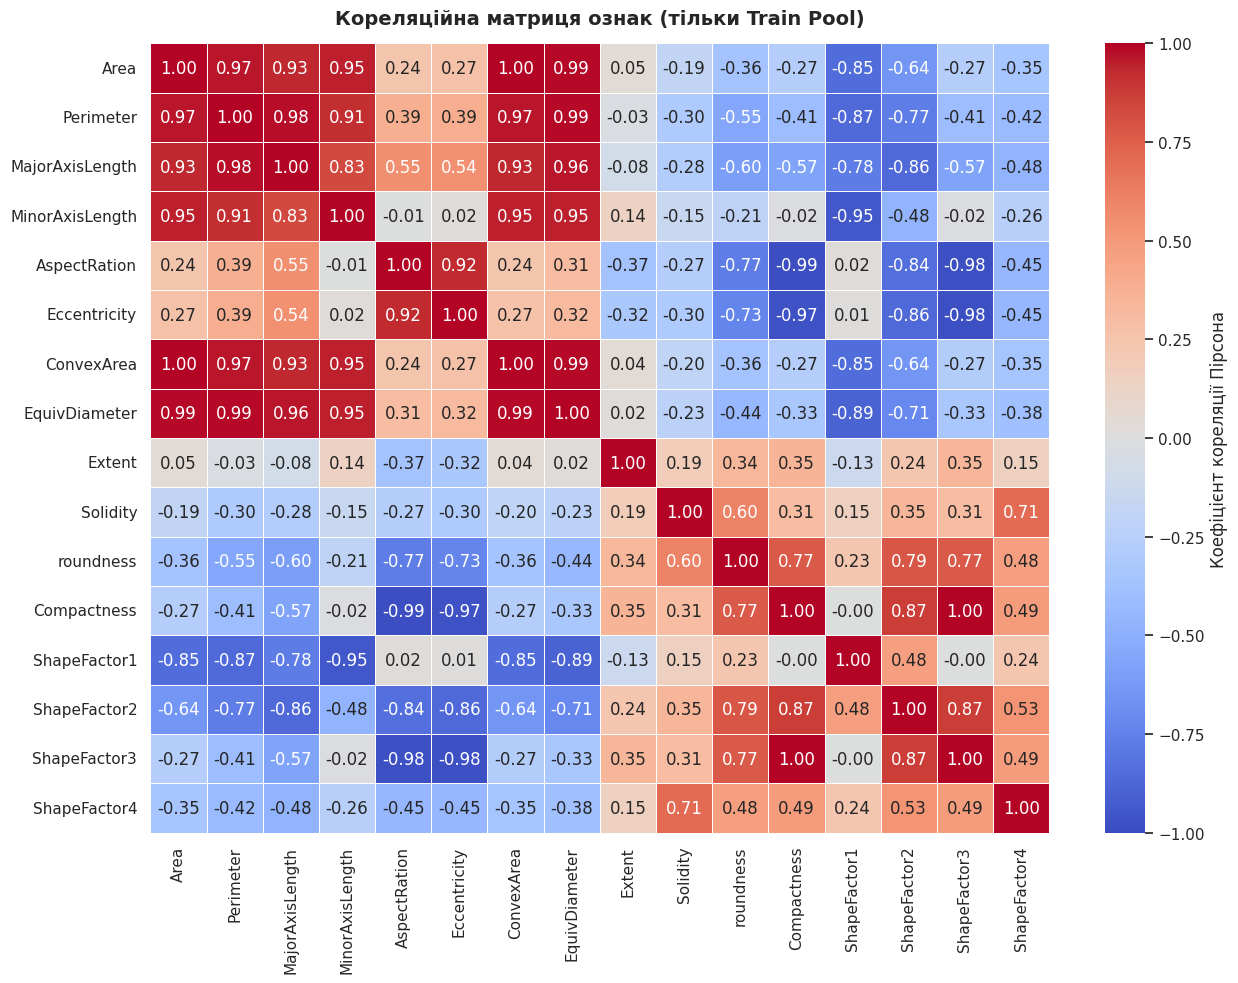

Пар ознак з |r| > 0.95: 15 (із 120 можливих)


,Ознака 1,Ознака 2,r
0,Area,ConvexArea,1.000
1,Compactness,ShapeFactor3,0.999
2,Perimeter,EquivDiameter,0.992
3,AspectRation,Compactness,-0.988
4,ConvexArea,EquivDiameter,0.985
5,Area,EquivDiameter,0.985
6,Eccentricity,ShapeFactor3,-0.981
7,AspectRation,ShapeFactor3,-0.978
8,Perimeter,MajorAxisLength,0.978
9,Eccentricity,Compactness,-0.970


In [6]:

# ==============================================================================
# 2.2 EDA ТА ВІДБІР ОЗНАК — ЛИШЕ НА TRAIN POOL (Val/Test НЕ використовуються)
# ==============================================================================
df_pool = pd.DataFrame(X_train_pool_raw, columns=feature_names)
df_pool['Class'] = [classes[i] for i in y_train_pool_idx]

# --- (а) Кореляції між ознаками (Train Pool) ---
corr_pool = df_pool[feature_names].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr_pool, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Коефіцієнт кореляції Пірсона'})
plt.title("Кореляційна матриця ознак (тільки Train Pool)", fontsize=14, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

pairs = [(a, b, corr_pool.loc[a, b]) for i, a in enumerate(feature_names) for b in feature_names[i+1:]
         if abs(corr_pool.loc[a, b]) > 0.95]
df_pairs = pd.DataFrame(pairs, columns=['Ознака 1', 'Ознака 2', 'r']).sort_values('r', key=np.abs, ascending=False)
print(f"Пар ознак з |r| > 0.95: {len(df_pairs)} (із {len(feature_names)*(len(feature_names)-1)//2} можливих)")
display(df_pairs.round(3).reset_index(drop=True))


Багато ознак майже копії одна одної: 15 пар із |r| > 0.95 (наприклад, Area і ConvexArea мають r = 1.00). Це логічно — усі вони описують розмір або форму того самого зерна. Для моделі це означає, що ваги можуть «розповзатись», хоча самі передбачення лишаються нормальними.

,Ознака,η²,ANOVA F,VIF
0,Area,0.928,20325,"84,546.2"
1,ConvexArea,0.928,20324,"82,202.6"
2,EquivDiameter,0.918,17790,"312,396.3"
3,Perimeter,0.916,17175,"3,920.1"
4,MinorAxisLength,0.909,15682,"76,513.0"
5,MajorAxisLength,0.906,15129,"87,348.2"
6,ShapeFactor2,0.844,8537,"1,224.4"
7,ShapeFactor1,0.844,8530,603.5
8,AspectRation,0.820,7171,"13,950.0"
9,Compactness,0.817,7043,"284,690.6"


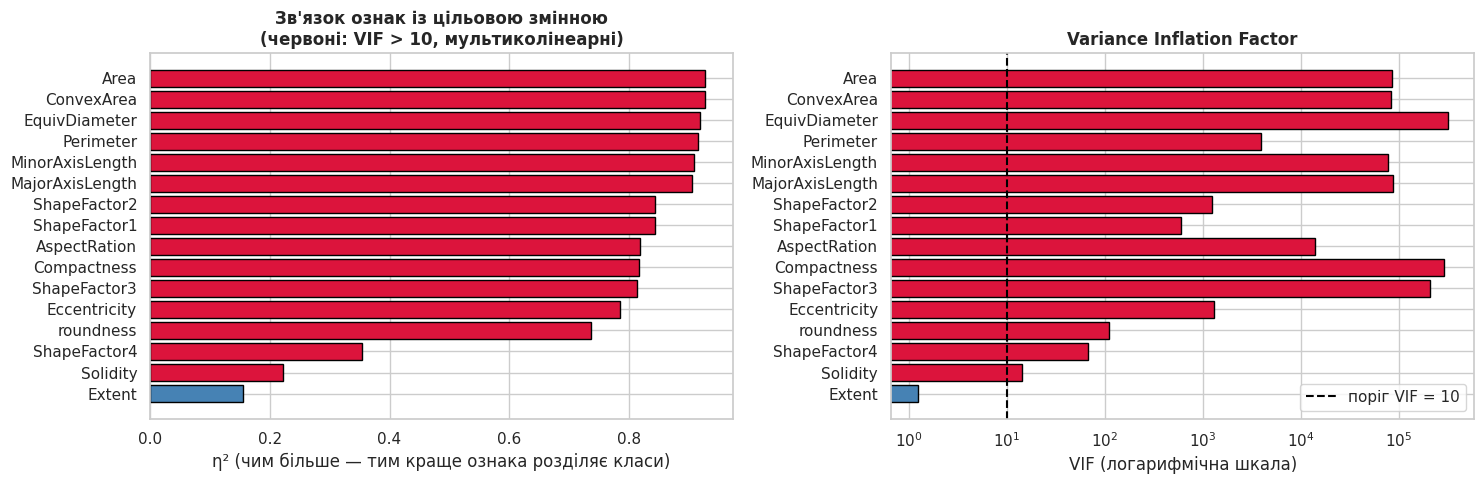

Ознак із VIF > 10: 15 із 16


In [7]:

# --- (б) Зв'язок «ознака → клас» та мультиколінеарність (VIF) ---
def eta_squared(X, y, n_cls):
    """Correlation ratio η² = SS_between / SS_total (частка дисперсії ознаки, що пояснюється класом)."""
    gm = X.mean(axis=0)
    ss_between = np.zeros(X.shape[1])
    for c in range(n_cls):
        Xc = X[y == c]
        ss_between += len(Xc) * (Xc.mean(axis=0) - gm) ** 2
    ss_total = ((X - gm) ** 2).sum(axis=0)
    return ss_between / ss_total

eta2 = eta_squared(X_train_pool_raw, y_train_pool_idx, num_classes)
n_pool = len(y_train_pool_idx)
anova_F = (eta2 / (num_classes - 1)) / ((1 - eta2) / (n_pool - num_classes))   # однофакторний ANOVA F
vif = np.diag(np.linalg.inv(corr_pool.values))                                  # VIF_j = [R^-1]_jj

df_feat = pd.DataFrame({'Ознака': feature_names, 'η²': eta2, 'ANOVA F': anova_F, 'VIF': vif}) \
            .sort_values('η²', ascending=False).reset_index(drop=True)
display(df_feat.style.format({'η²': '{:.3f}', 'ANOVA F': '{:.0f}', 'VIF': '{:,.1f}'}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_v = ['crimson' if v > 10 else 'steelblue' for v in df_feat['VIF']]
axes[0].barh(df_feat['Ознака'][::-1], df_feat['η²'][::-1], color=colors_v[::-1], edgecolor='black')
axes[0].set_xlabel("η² (чим більше — тим краще ознака розділяє класи)")
axes[0].set_title("Зв'язок ознак із цільовою змінною\n(червоні: VIF > 10, мультиколінеарні)", fontsize=12, fontweight='bold')
axes[1].barh(df_feat['Ознака'][::-1], df_feat['VIF'][::-1], color=colors_v[::-1], edgecolor='black')
axes[1].set_xscale('log'); axes[1].axvline(10, color='black', ls='--', label='поріг VIF = 10')
axes[1].set_xlabel("VIF (логарифмічна шкала)"); axes[1].legend()
axes[1].set_title("Variance Inflation Factor", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Ознак із VIF > 10: {(vif > 10).sum()} із {len(vif)}")


Майже всі ознаки добре розділяють класи (η² > 0.7 у 13 із 16), слабкі лише Extent (0.16) і Solidity (0.22). Але в 15 із 16 ознак VIF > 10, тобто вони дублюють одна одну. Отже, проблема не в поганих ознаках, а в тому, що їх забагато за змістом. Чи варто скорочувати набір, перевіряємо нижче.

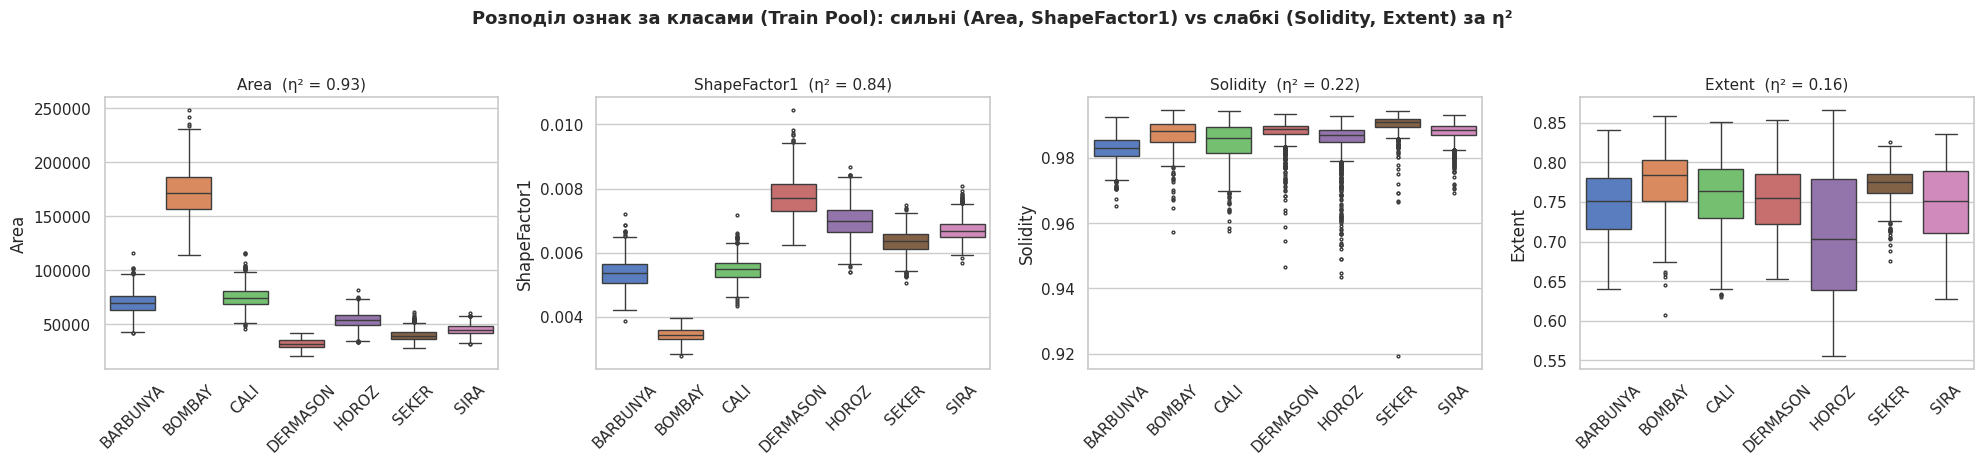

In [8]:

# --- (в) Розподіл ознак за класами: найсильніші та найслабші за η² ---
# Area — найсильніша (але дублюється ConvexArea), ShapeFactor1 — сильна ознака форми; Solidity та Extent — найслабші
sel_feats = ['Area', 'ShapeFactor1', 'Solidity', 'Extent']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, f in zip(axes, sel_feats):
    sns.boxplot(data=df_pool, x='Class', y=f, order=list(classes), hue='Class', hue_order=list(classes), legend=False, ax=ax, palette='muted', fliersize=2)
    ax.set_title(f"{f}  (η² = {df_feat.set_index('Ознака').loc[f, 'η²']:.2f})", fontsize=11)
    ax.tick_params(axis='x', rotation=45); ax.set_xlabel("")
plt.suptitle("Розподіл ознак за класами (Train Pool): сильні (Area, ShapeFactor1) vs слабкі (Solidity, Extent) за η²", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


За Area клас BOMBAY сильно відрізняється від решти (≈ 170 тис.), а DERMASON і SIRA лежать поруч і частково перекриваються. За Solidity та Extent усі класи перекриваються майже повністю. Тому очікуємо, що модель найбільше плутатиме саме DERMASON і SIRA.

## 3. Кодування та масштабування

**Кодування категоріальних ознак.** У Dry Bean усі 16 ознак числові, категоріальних немає, тому One-Hot / Ordinal / Target Encoding **не потрібні** (Target Encoding без потреби лише створював би ризик витоку). Цільова змінна `Class` перетворюється на індекси 0…6 та one-hot матрицю $Y \in \{0,1\}^{m \times 7}$ — це необхідно для cross-entropy.

**Масштабування.** Стандартизація $x' = (x - \mu)/\sigma$ з параметрами лише з Train Pool, застосована до Validation і Test. Реалізовано «більш федеративний» варіант (б): клієнти рахують $(n_k, \mu_k, \sigma_k^2)$, сервер агрегує.

In [9]:
# ==============================================================================
# 3. МАСШТАБУВАННЯ ОЗНАК (STANDARD SCALER: ЦЕНТРАЛІЗОВАНИЙ VS ФЕДЕРАТИВНИЙ)
# ==============================================================================
# (а) Централізоване обчислення
mean_central = np.mean(X_train_pool_raw, axis=0)
var_central = np.var(X_train_pool_raw, axis=0)
std_central = np.sqrt(var_central + 1e-12)

# (б) Федеративне обчислення (без передачі сирих даних на сервер).
# Тут 5 випадкових частин ІМІТУЮТЬ клієнтів: зважена агрегація (n_k, μ_k, σ²_k) дає ТОЧНО ті самі μ та σ²
# для будь-якого розбиття, тому це коректно й для Non-IID розподілів (перевіряється різницею нижче).
indices_demo = np.arange(len(X_train_pool_raw))
rng.shuffle(indices_demo)
client_chunks = np.array_split(indices_demo, 5)

local_stats = []
for chunk in client_chunks:
    X_k = X_train_pool_raw[chunk]
    local_stats.append((len(X_k), np.mean(X_k, axis=0), np.var(X_k, axis=0)))

# Серверна агрегація першого та другого моментів
N_total = sum(s[0] for s in local_stats)
mean_fed = sum(n_k * mu_k for n_k, mu_k, _ in local_stats) / N_total
E_x2_fed = sum(n_k * (var_k + mu_k**2) for n_k, mu_k, var_k in local_stats) / N_total
var_fed = E_x2_fed - mean_fed**2
std_fed = np.sqrt(np.maximum(var_fed, 0) + 1e-12)

# Перевірка збігу
diff_mean = np.max(np.abs(mean_central - mean_fed))
diff_std = np.max(np.abs(std_central - std_fed))
print(f"Різниця середніх (Central vs Fed):   {diff_mean:.4e}")
print(f"Різниця std (Central vs Fed):       {diff_std:.4e}")

# Застосування федеративного скейлера до всіх підвибірок (захист від ділення на нуль: EPSILON)
EPSILON = 1e-12
X_train_pool = (X_train_pool_raw - mean_fed) / (std_fed + EPSILON)
X_val = (X_val_raw - mean_fed) / (std_fed + EPSILON)
X_test = (X_test_raw - mean_fed) / (std_fed + EPSILON)

print(f"Масштабування завершено! Форма матриць: Train={X_train_pool.shape}, Val={X_val.shape}, Test={X_test.shape}")
N_FEATURES = X_train_pool.shape[1]   # кількість ознак (може змінитись після відбору ознак у п. 4.1)


Різниця середніх (Central vs Fed):   9.3792e-13
Різниця std (Central vs Fed):       2.5466e-11
Масштабування завершено! Форма матриць: Train=(9480, 16), Val=(2031, 16), Test=(2032, 16)


Середні та σ, порахувані по клієнтах і зведені на сервері, збігаються зі звичайними з точністю близько 10⁻¹². Так виходить, бо формули зваженого середнього й дисперсії точні, а не наближені, тож те, як розбито дані між клієнтами, на результат не впливає. Validation і Test в обчисленні не брали участі.

In [10]:
# ==============================================================================
# 4. ЛОГІСТИЧНА (SOFTMAX) РЕГРЕСІЯ НА ЧИСТОМУ NUMPY
# ==============================================================================

class SoftmaxRegression:
    def __init__(self, n_features, n_classes, lambda_reg=0.0, seed=42):
        """
        Багатокласова логістична регресія з L2-регуляризацією (Ridge).
        """
        self.n_features = n_features
        self.n_classes = n_classes
        self.lambda_reg = lambda_reg
        self.rng = np.random.default_rng(seed)
        
        # Ініціалізація ваг малими випадковими значеннями N(0, 0.01), bias - нулями
        self.W = self.rng.normal(loc=0.0, scale=0.01, size=(n_features, n_classes))
        self.b = np.zeros((1, n_classes))
        
    @staticmethod
    def softmax(Z):
        """Чисельно стійкий Softmax з відніманням максимуму по кожному рядку."""
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def predict_proba(self, X):
        """Обчислення ймовірностей класів для вибірки X: (m x C)."""
        Z = X @ self.W + self.b
        return self.softmax(Z)

    def predict(self, X):
        """Повертає цілочисельний індекс класу з найвищою ймовірністю."""
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def compute_loss(self, X, Y, W=None, b=None):
        """
        Cross-entropy loss + (lambda / 2) * ||W||_F^2.
        Зсув b не регуляризується.
        """
        if W is None: W = self.W
        if b is None: b = self.b
        
        m = X.shape[0]
        P = self.softmax(X @ W + b)
        # Кліпінг ймовірностей для запобігання log(0)
        P_clipped = np.clip(P, 1e-12, 1.0)
        
        cross_entropy = -np.sum(Y * np.log(P_clipped)) / m
        reg_loss = 0.5 * self.lambda_reg * np.sum(W ** 2)
        return cross_entropy + reg_loss

    def compute_gradients(self, X, Y, W=None, b=None):
        """
        Векторизовані градієнти без циклів по прикладах.
        dW = (1/m) X^T (P - Y) + lambda * W
        db = (1/m) sum(P - Y, axis=0)
        """
        if W is None: W = self.W
        if b is None: b = self.b
        
        m = X.shape[0]
        P = self.softmax(X @ W + b)
        diff = P - Y
        
        dW = (X.T @ diff) / m + self.lambda_reg * W
        db = np.sum(diff, axis=0, keepdims=True) / m
        return dW, db

    def fit(self, X_train, Y_train, X_val=None, Y_val=None, 
            learning_rate=0.1, epochs=50, batch_size=64, verbose=False):
        """Міні-батчевий SGD із відстеженням метрик за епохами."""
        m = X_train.shape[0]
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
        for epoch in range(epochs):
            # Перемішування тренувальної вибірки на початку кожної епохи
            indices = self.rng.permutation(m)
            X_shuffled = X_train[indices]
            Y_shuffled = Y_train[indices]
            
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                Y_batch = Y_shuffled[i:i + batch_size]
                
                dW, db = self.compute_gradients(X_batch, Y_batch)
                self.W -= learning_rate * dW
                self.b -= learning_rate * db
                
            # Запис динаміки навчання
            t_loss = self.compute_loss(X_train, Y_train)
            t_acc = np.mean(self.predict(X_train) == np.argmax(Y_train, axis=1))
            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            
            if X_val is not None and Y_val is not None:
                v_loss = self.compute_loss(X_val, Y_val)
                v_acc = np.mean(self.predict(X_val) == np.argmax(Y_val, axis=1))
                history['val_loss'].append(v_loss)
                history['val_acc'].append(v_acc)
                
            if verbose and (epoch + 1) % 10 == 0:
                print(f"Епоха {epoch+1:02d}/{epochs:02d} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")
                
        return history

In [11]:
# Перевірка 1: Сума ймовірностей по рядках = 1
model_check = SoftmaxRegression(n_features=N_FEATURES, n_classes=7, lambda_reg=0.01, seed=SEED)
sample_proba = model_check.predict_proba(X_train_pool[:10])
print(f"Перевірка суми ймовірностей (має бути 1.0): {np.allclose(sample_proba.sum(axis=1), 1.0)}")

# Перевірка 2: Loss при старті має бути приблизно ln(7) ≈ 1.9459
model_zero = SoftmaxRegression(n_features=N_FEATURES, n_classes=7, lambda_reg=0.0, seed=SEED)
model_zero.W = np.zeros((N_FEATURES, 7))
model_zero.b = np.zeros((1, 7))
init_loss = model_zero.compute_loss(X_train_pool, Y_train_pool)
print(f"Початковий Loss: {init_loss:.4f} (Теоретичний ln(7) = {np.log(7):.4f})")

# Перевірка 3: Чисельний Gradient Check на підвибірці (20 зразків)
eps = 1e-6
lambda_gc = 0.01
X_gc = X_train_pool[:20]
Y_gc = Y_train_pool[:20]

dW_analytic, db_analytic = model_check.compute_gradients(X_gc, Y_gc)

# Чисельний градієнт для W
dW_num = np.zeros_like(model_check.W)
for i in range(model_check.W.shape[0]):
    for j in range(model_check.W.shape[1]):
        W_pos = model_check.W.copy(); W_pos[i, j] += eps
        W_neg = model_check.W.copy(); W_neg[i, j] -= eps
        l_pos = model_check.compute_loss(X_gc, Y_gc, W=W_pos)
        l_neg = model_check.compute_loss(X_gc, Y_gc, W=W_neg)
        dW_num[i, j] = (l_pos - l_neg) / (2 * eps)

# Чисельний градієнт для b
db_num = np.zeros_like(model_check.b)
for j in range(model_check.b.shape[1]):
    b_pos = model_check.b.copy(); b_pos[0, j] += eps
    b_neg = model_check.b.copy(); b_neg[0, j] -= eps
    l_pos = model_check.compute_loss(X_gc, Y_gc, b=b_pos)
    l_neg = model_check.compute_loss(X_gc, Y_gc, b=b_neg)
    db_num[0, j] = (l_pos - l_neg) / (2 * eps)

rel_err_W = np.linalg.norm(dW_analytic - dW_num) / (np.linalg.norm(dW_analytic) + np.linalg.norm(dW_num))
rel_err_b = np.linalg.norm(db_analytic - db_num) / (np.linalg.norm(db_analytic) + np.linalg.norm(db_num))

print(f"Gradient Check відносна похибка для dW: {rel_err_W:.4e}")
print(f"Gradient Check відносна похибка для db: {rel_err_b:.4e}")

Перевірка суми ймовірностей (має бути 1.0): True
Початковий Loss: 1.9459 (Теоретичний ln(7) = 1.9459)
Gradient Check відносна похибка для dW: 4.9214e-10
Gradient Check відносна похибка для db: 6.1811e-10


Сума ймовірностей по рядках дорівнює 1, а стартовий loss = ln 7 ≈ 1.946, як і має бути для 7 класів. Перевірка градієнта дала похибку ≈ 5·10⁻¹⁰, отже формули градієнтів (разом із Ridge) правильні.

In [12]:
# ==============================================================================
# 5. МЕТРИКИ ОЦІНКИ ТА GRID SEARCH ДЛЯ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ
# ==============================================================================

def compute_metrics(y_true_idx, y_pred_idx, y_pred_proba, n_cls=7):
    """
    Обчислення accuracy, balanced accuracy, macro-F1, log-loss та матриці помилок на NumPy.
    """
    m = len(y_true_idx)
    acc = np.mean(y_true_idx == y_pred_idx)
    
    # Матриця невідповідностей (Confusion Matrix)
    cm = np.zeros((n_cls, n_cls), dtype=int)
    for t, p in zip(y_true_idx, y_pred_idx):
        cm[t, p] += 1
        
    # Recall, Precision та F1 по кожному класу
    recalls = []
    f1s = []
    for c in range(n_cls):
        tp = cm[c, c]
        fn = np.sum(cm[c, :]) - tp
        fp = np.sum(cm[:, c]) - tp
        
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
        
        recalls.append(rec)
        f1s.append(f1)
        
    balanced_acc = np.mean(recalls)
    macro_f1 = np.mean(f1s)
    
    # Log-Loss
    Y_onehot = np.eye(n_cls)[y_true_idx]
    P_clip = np.clip(y_pred_proba, 1e-12, 1.0)
    log_loss = -np.sum(Y_onehot * np.log(P_clip)) / m
    
    return {
        'accuracy': acc,
        'balanced_acc': balanced_acc,
        'macro_f1': macro_f1,
        'log_loss': log_loss,
        'confusion_matrix': cm
    }

## 4.1 Відбір ознак: повний набір vs набір без мультиколінеарності

За результатами EDA (п. 2.2) 15 із 16 ознак мають VIF > 10. Перевіряємо **на Global Validation**, чи покращує скорочення набору якість (5 ініціалізацій, фіксовані гіперпараметри lr = 0.1, batch = 64, λ = 10⁻³). Набір для скорочення визначається за кореляціями **Train Pool** (ітеративно видаляємо ознаку з максимальним VIF, доки VIF < 10). Правило рішення задано заздалегідь: скорочений набір беремо лише якщо він кращий за macro-F1 більш ніж на 0.3 п.п. і не гірший за log-loss.

In [13]:

# ==============================================================================
# 4.1 ВІДБІР ОЗНАК: ПОВНИЙ НАБІР vs НАБІР ПІСЛЯ ВИДАЛЕННЯ МУЛЬТИКОЛІНЕАРНОСТІ
# (рішення приймається ЛИШЕ за Global Validation; Global Test не використовується)
# ==============================================================================
def vif_reduce(X, thr=10.0):
    """Ітеративно видаляє ознаку з найбільшим VIF, доки max VIF >= thr (кореляції — на Train Pool)."""
    keep = list(range(X.shape[1]))
    while len(keep) > 2:
        R = np.corrcoef(X[:, keep], rowvar=False)
        v = np.diag(np.linalg.inv(R))
        if v.max() < thr:
            break
        keep.pop(int(np.argmax(v)))
    return keep

reduced_idx = vif_reduce(X_train_pool)
print("Залишено після VIF<10:", [feature_names[i] for i in reduced_idx])
print("Відкинуто:           ", [f for i, f in enumerate(feature_names) if i not in reduced_idx])

feature_sets = {f'Усі {N_FEATURES} ознак': list(range(N_FEATURES)),
                f'VIF<10 ({len(reduced_idx)} ознак)': reduced_idx}
rows = []
for set_name, idx in feature_sets.items():
    for s in range(5):   # 5 ініціалізацій, фіксовані гіперпараметри (lr=0.1, bs=64, λ=1e-3)
        m = SoftmaxRegression(len(idx), num_classes, lambda_reg=1e-3, seed=SEED + s)
        m.fit(X_train_pool[:, idx], Y_train_pool, learning_rate=0.1, epochs=40, batch_size=64)
        p = m.predict_proba(X_val[:, idx])
        mt = compute_metrics(y_val_idx, p.argmax(1), p, n_cls=num_classes)
        rows.append({'Набір ознак': set_name, 'val_acc': mt['accuracy']*100, 'val_macroF1': mt['macro_f1']*100, 'val_logloss': mt['log_loss']})
df_fs = pd.DataFrame(rows).groupby('Набір ознак', sort=False).agg(['mean', 'std']).round(3)
display(df_fs)

names_fs = list(feature_sets)
f1_full, f1_red = [df_fs.loc[n, ('val_macroF1', 'mean')] for n in names_fs]
ll_full, ll_red = [df_fs.loc[n, ('val_logloss', 'mean')] for n in names_fs]
# Правило рішення: скорочений набір беремо, лише якщо він кращий за macro-F1 (> +0.3 п.п.) і не гірший за log-loss
USE_REDUCED = (f1_red - f1_full > 0.3) and (ll_red <= ll_full)
print(f"\nmacro-F1: повний {f1_full:.2f} vs скорочений {f1_red:.2f} | log-loss: повний {ll_full:.4f} vs скорочений {ll_red:.4f}")
print(f"РІШЕННЯ: {'використовуємо скорочений набір' if USE_REDUCED else 'залишаємо всі ознаки'}")

if USE_REDUCED:
    X_train_pool, X_val, X_test = X_train_pool[:, reduced_idx], X_val[:, reduced_idx], X_test[:, reduced_idx]
    feature_names = [feature_names[i] for i in reduced_idx]
    N_FEATURES = len(reduced_idx)
print(f"N_FEATURES = {N_FEATURES}")


Залишено після VIF<10: ['Eccentricity', 'ConvexArea', 'Extent', 'Solidity', 'roundness', 'ShapeFactor1', 'ShapeFactor4']
Відкинуто:            ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'EquivDiameter', 'Compactness', 'ShapeFactor2', 'ShapeFactor3']


val_acc        val_macroF1        val_logloss     
                    mean    std        mean    std        mean  std
Набір ознак                                                        
Усі 16 ознак      91.758  0.082      92.788  0.066       0.238  0.0
VIF<10 (7 ознак)  91.699  0.075      92.788  0.042       0.272  0.0


macro-F1: повний 92.79 vs скорочений 92.79 | log-loss: повний 0.2380 vs скорочений 0.2720
РІШЕННЯ: залишаємо всі ознаки
N_FEATURES = 16


Скорочений набір із 7 ознак дає той самий macro-F1 (92.79 в обох випадках) і майже ту саму accuracy (91.70 проти 91.76), але гірший log-loss (0.272 проти 0.238). Тобто дублюючі ознаки не заважають класифікувати, а навіть трохи допомагають з якістю ймовірностей. Тому залишаємо всі 16, а з дублюванням справляється Ridge. Якщо б головним був розмір моделі для передачі по мережі, 7 ознак були б прийнятним компромісом (56 параметрів проти 119).

In [14]:
# Сітка гіперпараметрів
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'batch_size': [32, 64, 128],
    'lambda_reg': [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
}

results = []
print("Пошук оптимальних гіперпараметрів на Global Validation...")

for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        for lmb in param_grid['lambda_reg']:
            model = SoftmaxRegression(n_features=N_FEATURES, n_classes=7, lambda_reg=lmb, seed=SEED)
            model.fit(X_train_pool, Y_train_pool, X_val, Y_val, 
                      learning_rate=lr, epochs=40, batch_size=bs, verbose=False)
            
            p_val = model.predict_proba(X_val)
            pred_val = np.argmax(p_val, axis=1)
            metrics = compute_metrics(y_val_idx, pred_val, p_val, n_cls=7)
            
            results.append({
                'lr': lr, 'batch_size': bs, 'lambda': lmb,
                'val_acc': metrics['accuracy'],
                'val_f1': metrics['macro_f1'],
                'val_loss': metrics['log_loss']
            })

df_grid = pd.DataFrame(results).sort_values(by=['val_f1', 'val_loss'], ascending=[False, True]).reset_index(drop=True)
print("\nТоп-5 конфігурацій за macro-F1 на валідації (критерій вибору: macro-F1, при рівності — менший log-loss):")
display(df_grid.head(5))

best_params = df_grid.iloc[0]
print(f"\nОптимальні параметри: lr={best_params['lr']}, batch_size={int(best_params['batch_size'])}, lambda={best_params['lambda']}")

Пошук оптимальних гіперпараметрів на Global Validation...



Топ-5 конфігурацій за macro-F1 на валідації (критерій вибору: macro-F1, при рівності — менший log-loss):


,lr,batch_size,lambda,val_acc,val_f1,val_loss
0,0.20,32,0.0000,0.919744,0.930633,0.219944
1,0.20,32,0.0001,0.919252,0.930307,0.221039
2,0.20,64,0.0000,0.917774,0.929143,0.222457
3,0.05,64,0.0001,0.918759,0.929039,0.239676
4,0.05,64,0.0000,0.918267,0.928613,0.238976



Оптимальні параметри: lr=0.2, batch_size=32, lambda=0.0


Найкращі налаштування: lr = 0.2, batch = 32, λ = 0 (вибирали за macro-F1 на Validation). П'ять кращих конфігурацій дають майже однаковий результат (≈ 93% F1), різниця менша за шум між запусками. Менший batch дає більше оновлень за ті самі епохи, тому модель навчається краще.

val_f1          val_acc         val_logloss           W_norm        
           mean     std     mean     std        mean     std     mean     std
lambda                                                                       
0.0000  93.0029  0.2605  91.9252  0.2741      0.2204  0.0011  12.3163  0.0078
0.0001  93.0172  0.1815  91.9252  0.1969      0.2214  0.0011  11.5733  0.0074
0.0010  92.7917  0.0533  91.6790  0.1477      0.2353  0.0010   8.6515  0.0053
0.0100  92.1889  0.0494  90.9732  0.1025      0.3219  0.0007   4.9786  0.0087
0.1000  89.5998  0.5812  88.2160  0.5874      0.6304  0.0013   2.2396  0.0040
0.3000  79.1497  3.6387  77.3839  3.1682      0.8924  0.0085   1.3792  0.0150
1.0000  48.3254  6.6548  51.8956  3.7371      1.2225  0.0148   0.7436  0.0472

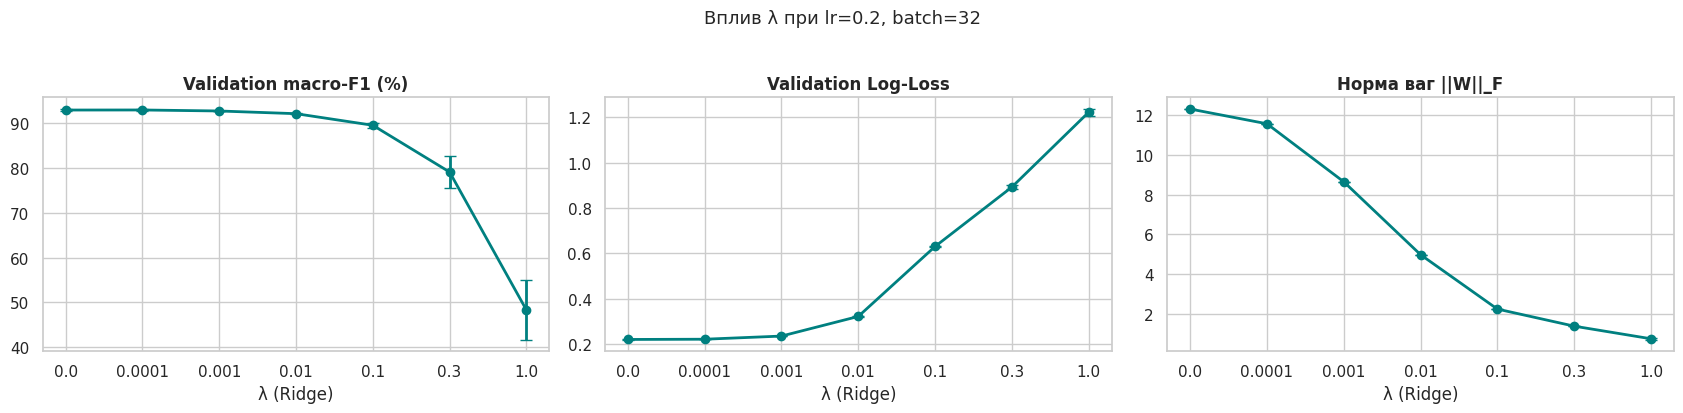

In [15]:

# ==============================================================================
# 5.1 ВПЛИВ RIDGE-РЕГУЛЯРИЗАЦІЇ (λ) — за Global Validation, 3 ініціалізації
# ==============================================================================
lr_b, bs_b = float(best_params['lr']), int(best_params['batch_size'])
lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 3e-1, 1.0]
ridge_rows = []
for lmb in lambdas:
    for s in range(3):
        m = SoftmaxRegression(N_FEATURES, num_classes, lambda_reg=lmb, seed=SEED + s)
        m.fit(X_train_pool, Y_train_pool, learning_rate=lr_b, epochs=40, batch_size=bs_b)
        p = m.predict_proba(X_val)
        mt = compute_metrics(y_val_idx, p.argmax(1), p, n_cls=num_classes)
        ridge_rows.append({'lambda': lmb, 'val_f1': mt['macro_f1']*100, 'val_acc': mt['accuracy']*100,
                           'val_logloss': mt['log_loss'], 'W_norm': np.linalg.norm(m.W)})
df_ridge = pd.DataFrame(ridge_rows).groupby('lambda').agg(['mean', 'std'])
display(df_ridge.round(4))

xl = [str(l) for l in lambdas]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, ttl in zip(axes, ['val_f1', 'val_logloss', 'W_norm'],
                        ['Validation macro-F1 (%)', 'Validation Log-Loss', "Норма ваг ||W||_F"]):
    ax.errorbar(xl, df_ridge[(col, 'mean')], yerr=df_ridge[(col, 'std')], fmt='-o', capsize=4, lw=2, color='teal')
    ax.set_title(ttl, fontsize=12, fontweight='bold'); ax.set_xlabel("λ (Ridge)")
plt.suptitle(f"Вплив λ при lr={lr_b}, batch={bs_b}", fontsize=13, y=1.03); plt.tight_layout(); plt.show()


Чим більше λ, тим гірше: до λ = 10⁻⁴ macro-F1 ≈ 93%, при λ = 0.1 уже 89.6%, а при λ = 1 лише 48%. Ваги при цьому стискаються (норма падає з 12.3 до 0.74). Регуляризація тут не потрібна: даних багато (9 480), а параметрів мало (119), тому перенавчання немає і штраф тільки заважає. У федеративному навчанні беремо λ = 10⁻⁴ — якість та сама, а ваги трохи менші.

Епоха 10/80 | Train Loss: 0.2162 | Val Loss: 0.2291 | Val Acc: 0.9183
Епоха 20/80 | Train Loss: 0.2120 | Val Loss: 0.2233 | Val Acc: 0.9148


Епоха 30/80 | Train Loss: 0.2106 | Val Loss: 0.2207 | Val Acc: 0.9207
Епоха 40/80 | Train Loss: 0.2101 | Val Loss: 0.2199 | Val Acc: 0.9197


Епоха 50/80 | Train Loss: 0.2103 | Val Loss: 0.2193 | Val Acc: 0.9168


Епоха 60/80 | Train Loss: 0.2089 | Val Loss: 0.2189 | Val Acc: 0.9202
Епоха 70/80 | Train Loss: 0.2082 | Val Loss: 0.2182 | Val Acc: 0.9207


Епоха 80/80 | Train Loss: 0.2080 | Val Loss: 0.2184 | Val Acc: 0.9188


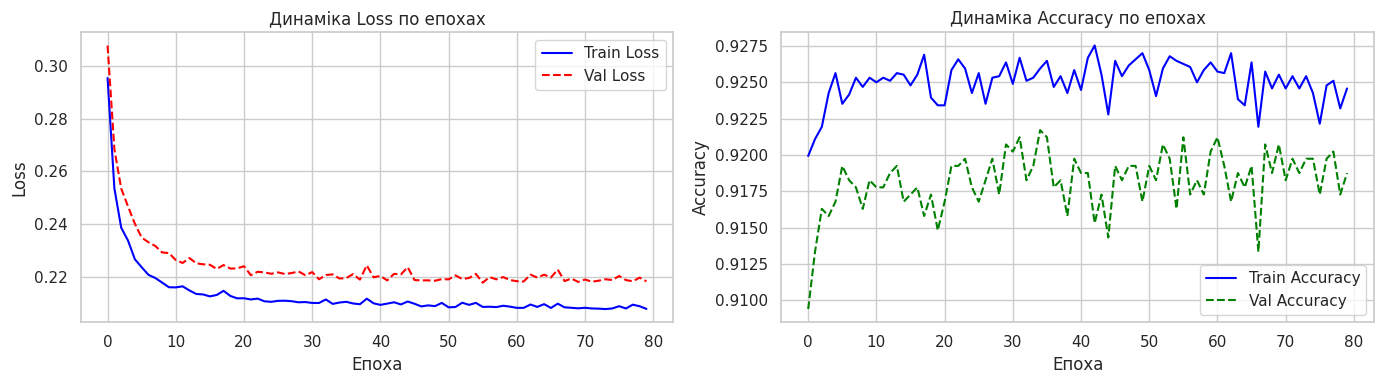

ФІНАЛЬНІ РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:
  Accuracy:          91.98%
  Balanced Accuracy: 93.23%
  Macro-F1:          93.23%
  Log-Loss:          0.2222


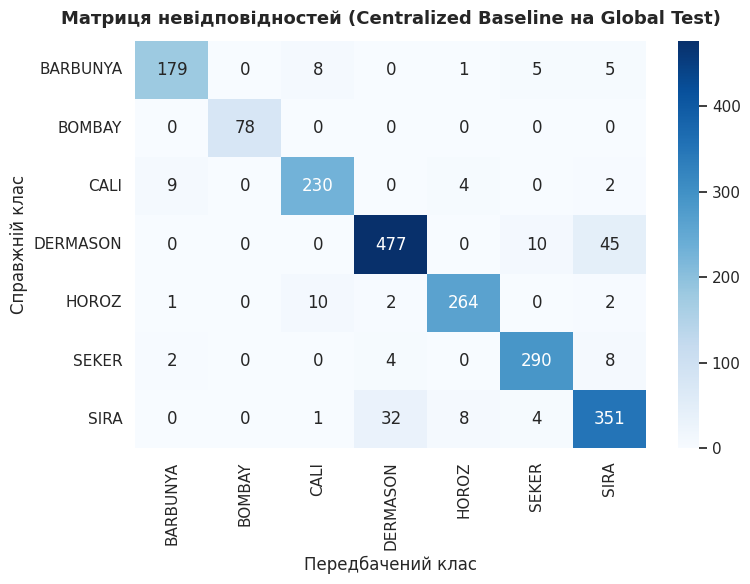

In [16]:
# Навчання централізованого бейзлайну з оптимальними параметрами на 80 епох
best_model = SoftmaxRegression(
    n_features=N_FEATURES, n_classes=7, 
    lambda_reg=float(best_params['lambda']), 
    seed=SEED
)

history = best_model.fit(
    X_train_pool, Y_train_pool, X_val, Y_val,
    learning_rate=float(best_params['lr']),
    epochs=80,
    batch_size=int(best_params['batch_size']),
    verbose=True
)

# Графіки збіжності Train vs Validation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[0].set_title("Динаміка Loss по епохах")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green', linestyle='--')
axes[1].set_title("Динаміка Accuracy по епохах")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# ФІНАЛЬНА ОЦІНКА НА GLOBAL TEST (ВИКОРИСТОВУЄТЬСЯ СТРОГО 1 РАЗ)
# ------------------------------------------------------------------------------
p_test = best_model.predict_proba(X_test)
pred_test = np.argmax(p_test, axis=1)
test_metrics = compute_metrics(y_test_idx, pred_test, p_test, n_cls=7)

print("=" * 60)
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:")
print(f"  Accuracy:          {test_metrics['accuracy'] * 100:.2f}%")
print(f"  Balanced Accuracy: {test_metrics['balanced_acc'] * 100:.2f}%")
print(f"  Macro-F1:          {test_metrics['macro_f1'] * 100:.2f}%")
print(f"  Log-Loss:          {test_metrics['log_loss']:.4f}")
print("=" * 60)

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    test_metrics['confusion_matrix'], 
    annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes
)
plt.title("Матриця невідповідностей (Centralized Baseline на Global Test)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.tight_layout()
plt.show()

In [17]:

# Якість по класах (Global Test): recall та F1 кожного класу
cm_ = test_metrics['confusion_matrix']
rec_ = np.diag(cm_) / cm_.sum(axis=1)
prec_ = np.diag(cm_) / np.maximum(cm_.sum(axis=0), 1)
df_cls = pd.DataFrame({'Клас': classes, 'Кількість у Test': cm_.sum(axis=1), 'Recall (%)': rec_*100,
                       'Precision (%)': prec_*100, 'F1 (%)': 2*prec_*rec_/(prec_+rec_)*100}).round(2)
display(df_cls)
off = cm_.copy(); np.fill_diagonal(off, 0)
top_err = sorted([(off[i, j], classes[i], classes[j]) for i in range(num_classes) for j in range(num_classes) if off[i, j] > 0], reverse=True)[:4]
print("Найчастіші помилки (справжній → передбачений):", [(f"{a}→{b}", int(n)) for n, a, b in top_err])


,Клас,Кількість у Test,Recall (%),Precision (%),F1 (%)
0,BARBUNYA,198,90.40,93.72,92.03
1,BOMBAY,78,100.00,100.00,100.00
2,CALI,245,93.88,92.37,93.12
3,DERMASON,532,89.66,92.62,91.12
4,HOROZ,279,94.62,95.31,94.96
5,SEKER,304,95.39,93.85,94.62
6,SIRA,396,88.64,84.99,86.77


Найчастіші помилки (справжній → передбачений): [('DERMASON→SIRA', 45), ('SIRA→DERMASON', 32), ('HOROZ→CALI', 10), ('DERMASON→SEKER', 10)]


Результат на Global Test: accuracy 91.98%, balanced accuracy 93.23%, macro-F1 93.23%, log-loss 0.222. Криві train і validation збігаються, тож перенавчання немає. Найчастіше модель плутає DERMASON і SIRA (77 із ≈ 163 помилок), а BOMBAY розпізнає ідеально. Це приблизно межа для лінійної моделі, і саме з нею порівнюємо федеративні варіанти.

## 6. Розподіл FL Train Pool між клієнтами

K = 5 клієнтів, фіксований сід. Кожен приклад Train Pool належить **рівно одному** клієнту (перевіряється нижче: сума n_k = 9 480, без перетинів). Варіанти: **IID** (стратифіковано, рівні частини) та **Non-IID** через Dirichlet(α) по кожному класу, α ∈ {5, 1, 0.3}; перевіряється, що немає клієнтів із n_k < 10.

In [18]:
# ==============================================================================
# 6. РОЗПОДІЛ ДАНИХ FL TRAIN POOL МІЖ КЛІЄНТАМИ (IID ТА NON-IID)
# ==============================================================================

def create_iid_partitions(y_indices, n_clients=5, seed=42):
    """
    IID: Стратифікований та рівномірний розподіл прикладів між клієнтами.
    Кожен клієнт отримує однакові частки кожного класу.
    """
    local_rng = np.random.default_rng(seed)
    client_indices = {k: [] for k in range(n_clients)}
    
    for c in np.unique(y_indices):
        c_idxs = np.where(y_indices == c)[0]
        local_rng.shuffle(c_idxs)
        splits = np.array_split(c_idxs, n_clients)
        for k in range(n_clients):
            client_indices[k].extend(splits[k])
            
    # Перемішуємо індекси всередині кожного клієнта
    for k in range(n_clients):
        local_rng.shuffle(client_indices[k])
        client_indices[k] = np.array(client_indices[k])
        
    return client_indices


def create_non_iid_dirichlet(y_indices, n_clients=5, alpha=1.0, min_size=10, seed=42, max_retries=100):
    """
    Non-IID поділ через симетричний розподіл Діріхле Dir(alpha).
    Для кожного класу генерується вектор часток p_c ~ Dir(alpha, ..., alpha).
    Індекси класу розбиваються згідно з cumsum(p_c).
    Включає захист від клієнтів із кількістю зразків < min_size.
    """
    for attempt in range(max_retries):
        local_rng = np.random.default_rng(seed + attempt * 100)
        client_indices = {k: [] for k in range(n_clients)}
        
        for c in np.unique(y_indices):
            c_idxs = np.where(y_indices == c)[0]
            local_rng.shuffle(c_idxs)
            n_c = len(c_idxs)
            
            # Генеруємо частки для кожного клієнта
            proportions = local_rng.dirichlet(np.repeat(alpha, n_clients))
            
            # Обчислюємо точки розрізу масиву
            split_points = (np.cumsum(proportions) * n_c).astype(int)[:-1]
            c_splits = np.split(c_idxs, split_points)
            
            for k in range(n_clients):
                client_indices[k].extend(c_splits[k])
                
        # Перевірка: кожен клієнт повинен мати >= min_size зразків
        sizes = [len(client_indices[k]) for k in range(n_clients)]
        if min(sizes) >= min_size:
            for k in range(n_clients):
                local_rng.shuffle(client_indices[k])
                client_indices[k] = np.array(client_indices[k])
            return client_indices

    raise RuntimeError(f"Не вдалося згенерувати валідний розподіл для alpha={alpha} за {max_retries} спроб.")

# Генеруємо розбиття для 4 конфігурацій: IID, alpha=5.0, alpha=1.0, alpha=0.3
K_CLIENTS = 5
partitions = {
    'IID': create_iid_partitions(y_train_pool_idx, n_clients=K_CLIENTS, seed=SEED),
    'Non-IID (α=5)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=5.0, seed=SEED),
    'Non-IID (α=1)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=1.0, seed=SEED),
    'Non-IID (α=0.3)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=0.3, seed=SEED)
}

# Валідація коректності розбиття (Checklist)
print("--- ВАЛІДАЦІЯ РОЗПОДІЛІВ FL TRAIN POOL ---")
N_TOTAL_TRAIN = len(y_train_pool_idx)

for name, part in partitions.items():
    total_samples = sum(len(idxs) for idxs in part.values())
    all_indices = np.concatenate(list(part.values()))
    unique_indices = np.unique(all_indices)
    
    is_sum_exact = (total_samples == N_TOTAL_TRAIN)
    no_overlap = (len(unique_indices) == N_TOTAL_TRAIN)
    min_k = min(len(idxs) for idxs in part.values())
    
    print(f"[{name:15s}] Сума збігається: {is_sum_exact} | Перетинів немає: {no_overlap} | Min n_k: {min_k} зразків")

--- ВАЛІДАЦІЯ РОЗПОДІЛІВ FL TRAIN POOL ---
[IID            ] Сума збігається: True | Перетинів немає: True | Min n_k: 1894 зразків
[Non-IID (α=5)  ] Сума збігається: True | Перетинів немає: True | Min n_k: 1585 зразків
[Non-IID (α=1)  ] Сума збігається: True | Перетинів немає: True | Min n_k: 1241 зразків
[Non-IID (α=0.3)] Сума збігається: True | Перетинів немає: True | Min n_k: 1048 зразків


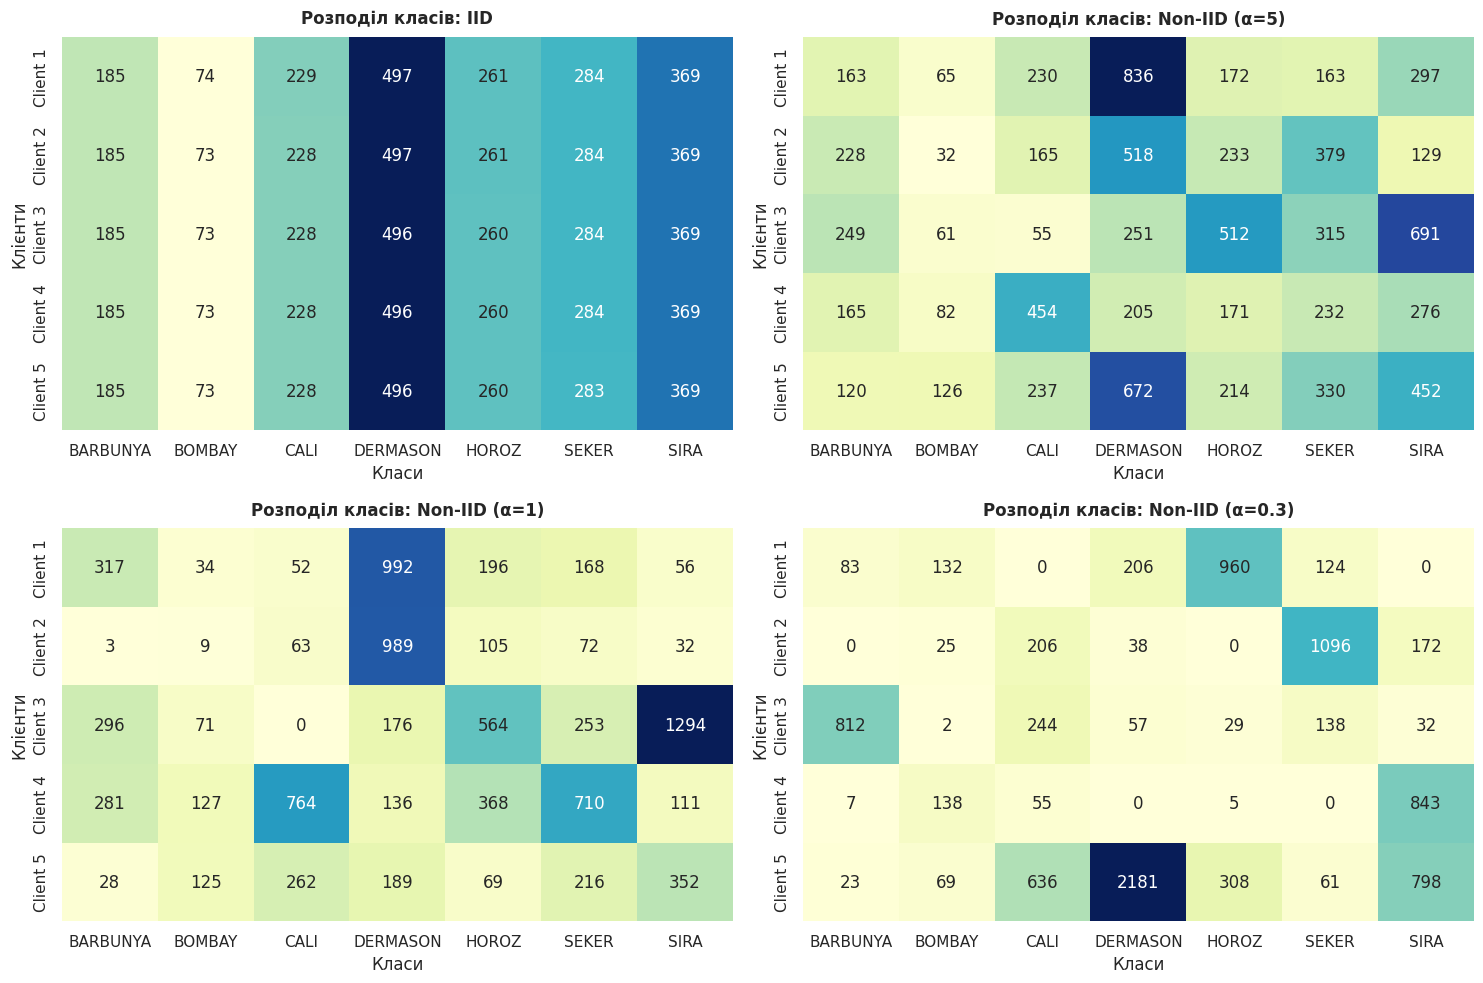

In [19]:
# Візуалізація розподілу класів для кожного клієнта
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, (name, part) in enumerate(partitions.items()):
    matrix = np.zeros((K_CLIENTS, num_classes), dtype=int)
    for k in range(K_CLIENTS):
        counts = np.bincount(y_train_pool_idx[part[k]], minlength=num_classes)
        matrix[k] = counts
        
    df_part = pd.DataFrame(matrix, index=[f"Client {k+1}" for k in range(K_CLIENTS)], columns=classes)
    
    sns.heatmap(df_part, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[ax_idx])
    axes[ax_idx].set_title(f"Розподіл класів: {name}", fontsize=12, fontweight='bold', pad=10)
    axes[ax_idx].set_ylabel("Клієнти")
    axes[ax_idx].set_xlabel("Класи")

plt.tight_layout()
plt.show()

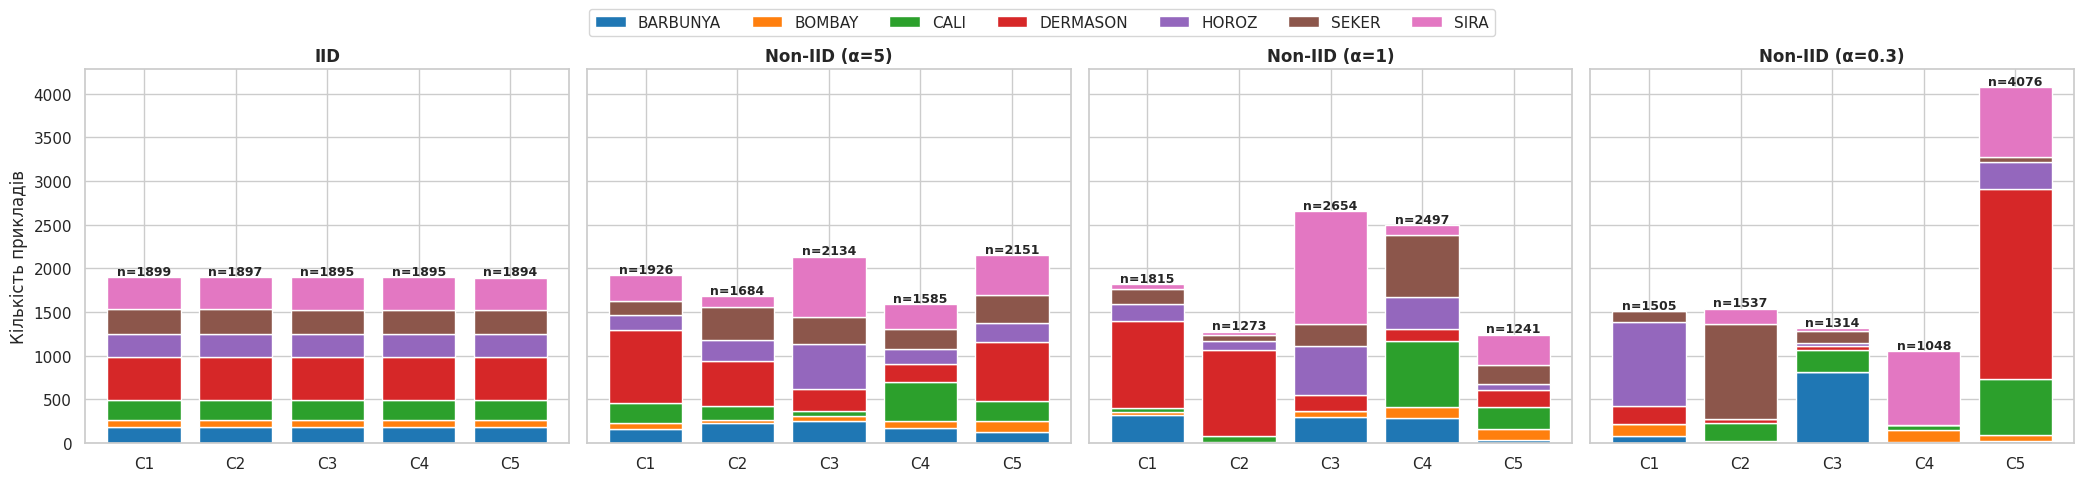

,Розподіл,Клієнт,n_k,Класів представлено (з 7),Домінантний клас,Частка домінантного (%)
0,IID,1,1899,7,DERMASON,26.2
1,IID,2,1897,7,DERMASON,26.2
2,IID,3,1895,7,DERMASON,26.2
3,IID,4,1895,7,DERMASON,26.2
4,IID,5,1894,7,DERMASON,26.2
15,Non-IID (α=0.3),1,1505,5,HOROZ,63.8
16,Non-IID (α=0.3),2,1537,5,SEKER,71.3
17,Non-IID (α=0.3),3,1314,7,BARBUNYA,61.8
18,Non-IID (α=0.3),4,1048,5,SIRA,80.4
19,Non-IID (α=0.3),5,4076,7,DERMASON,53.5


Клієнтів із n_k < 10 у всіх розподілах: 0


In [20]:

# Стовпчикова діаграма: кількість прикладів у кожного клієнта (n_k), розбита за класами
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6), sharey=True)
palette = sns.color_palette('tab10', num_classes)
for ax, (name, part) in zip(axes, partitions.items()):
    bottom = np.zeros(K_CLIENTS)
    for c in range(num_classes):
        counts = np.array([np.sum(y_train_pool_idx[part[k]] == c) for k in range(K_CLIENTS)])
        ax.bar(range(K_CLIENTS), counts, bottom=bottom, color=palette[c], edgecolor='white',
               label=classes[c] if ax is axes[0] else None)
        bottom += counts
    for k in range(K_CLIENTS):
        ax.text(k, bottom[k] + 25, f"n={int(bottom[k])}", ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(K_CLIENTS)); ax.set_xticklabels([f"C{k+1}" for k in range(K_CLIENTS)])
    ax.set_title(name, fontsize=12, fontweight='bold')
axes[0].set_ylabel("Кількість прикладів"); fig.legend(loc='upper center', ncol=num_classes, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

# Документація розподілу: n_k, кількість представлених класів, частка домінантного класу
doc_rows = []
for name, part in partitions.items():
    for k in range(K_CLIENTS):
        cnt = np.bincount(y_train_pool_idx[part[k]], minlength=num_classes)
        doc_rows.append({'Розподіл': name, 'Клієнт': k+1, 'n_k': cnt.sum(), 'Класів представлено (з 7)': int((cnt > 0).sum()),
                         'Домінантний клас': classes[cnt.argmax()], 'Частка домінантного (%)': round(cnt.max()/cnt.sum()*100, 1)})
df_doc = pd.DataFrame(doc_rows)
display(df_doc[df_doc['Розподіл'].isin(['IID', 'Non-IID (α=0.3)'])])
print("Клієнтів із n_k < 10 у всіх розподілах:", int((df_doc['n_k'] < 10).sum()))


В IID усі клієнти мають по ≈ 1 895 прикладів і всі 7 класів. Зі зменшенням α клієнти стають різними: при α = 0.3 розміри від 1 048 до 4 076, три клієнти мають лише 5 із 7 класів, а в клієнта 4 80% даних — SIRA. Клієнтів із менш ніж 10 прикладів немає. Через це кожен клієнт «тягне» модель у бік своїх класів, і саме звідси проблеми Non-IID.

In [21]:

# ==============================================================================
# 7. АЛГОРИТМ ФЕДЕРАТИВНОГО УСЕРЕДНЕННЯ (FEDAVG) + вимірювання client drift
# ==============================================================================

def train_fedavg(
    partitions_dict,
    X_train_full, Y_train_full,
    X_val, Y_val, y_val_idx,
    X_test, Y_test, y_test_idx,
    rounds=40, local_epochs=3, batch_size=32, lr=0.2,
    lambda_reg=1e-4, weighted=True, seed=42
):
    """
    Federated Averaging (FedAvg), усі клієнти беруть участь у кожному раунді.
    - weighted=True : w_new = sum_k (n_k / N) * w_k
    - weighted=False: w_new = (1/K) * sum_k w_k
    Додатково записується client drift:  drift_t = sum_k (n_k/N) * ||w_k^{t+1} - w^t||_F,
    тобто наскільки далеко локальні моделі "розбігаються" від глобальної за один раунд.
    Сервер використовує лише Global Validation (моніторинг); Global Test — тільки в кінці.
    """
    n_clients = len(partitions_dict)
    n_features = X_train_full.shape[1]
    n_classes = Y_train_full.shape[1]

    global_model = SoftmaxRegression(n_features, n_classes, lambda_reg=lambda_reg, seed=seed)

    n_k_list = np.array([len(partitions_dict[k]) for k in range(n_clients)])
    N_total = np.sum(n_k_list)
    client_weights = n_k_list / N_total if weighted else np.ones(n_clients) / n_clients
    drift_weights = n_k_list / N_total

    history = {'val_loss': [], 'val_acc': [], 'val_f1': [], 'drift': []}

    for r in range(rounds):
        local_W_list, local_b_list, drifts = [], [], []

        for k in range(n_clients):
            k_idxs = partitions_dict[k]
            X_k, Y_k = X_train_full[k_idxs], Y_train_full[k_idxs]

            local_model = SoftmaxRegression(n_features, n_classes, lambda_reg=lambda_reg, seed=seed + r*n_clients + k)
            local_model.W = global_model.W.copy()
            local_model.b = global_model.b.copy()

            local_model.fit(X_k, Y_k, learning_rate=lr, epochs=local_epochs, batch_size=batch_size, verbose=False)

            drifts.append(np.sqrt(np.sum((local_model.W - global_model.W) ** 2) + np.sum((local_model.b - global_model.b) ** 2)))
            local_W_list.append(local_model.W)
            local_b_list.append(local_model.b)

        # Серверна агрегація параметрів
        global_W_new = np.zeros_like(global_model.W)
        global_b_new = np.zeros_like(global_model.b)
        for k in range(n_clients):
            global_W_new += client_weights[k] * local_W_list[k]
            global_b_new += client_weights[k] * local_b_list[k]
        global_model.W, global_model.b = global_W_new, global_b_new

        # Оцінка глобальної моделі на Global Validation
        p_val = global_model.predict_proba(X_val)
        v_metrics = compute_metrics(y_val_idx, np.argmax(p_val, axis=1), p_val, n_cls=n_classes)
        history['val_loss'].append(v_metrics['log_loss'])
        history['val_acc'].append(v_metrics['accuracy'])
        history['val_f1'].append(v_metrics['macro_f1'])
        history['drift'].append(float(np.sum(drift_weights * np.array(drifts))))

    # Фінальна оцінка глобальної моделі на Global Test
    p_test = global_model.predict_proba(X_test)
    test_metrics_fl = compute_metrics(y_test_idx, np.argmax(p_test, axis=1), p_test, n_cls=n_classes)
    return global_model, history, test_metrics_fl


In [22]:
ROUNDS = 40
LOCAL_EPOCHS = 3
BATCH_SIZE = 32
LR = 0.2
LAMBDA = 1e-4

print("Запуск експериментів FedAvg...")

# 1. FedAvg на IID
print("1. FedAvg на IID даних...")
fed_iid_model, hist_iid, test_iid = train_fedavg(
    partitions['IID'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=True, seed=SEED
)

# 2. FedAvg на Non-IID (alpha=0.3) зі зважуванням
print("2. FedAvg на Non-IID (α=0.3) Зважений...")
fed_noniid_w_model, hist_noniid_w, test_noniid_w = train_fedavg(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=True, seed=SEED
)

# 3. FedAvg на Non-IID (alpha=0.3) БЕЗ зважування (просте середнє)
print("3. FedAvg на Non-IID (α=0.3) БЕЗ зважування...")
fed_noniid_unw_model, hist_noniid_unw, test_noniid_unw = train_fedavg(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=False, seed=SEED
)

# Зведення фінальних результатів на Global Test
df_fed_compare = pd.DataFrame([
    {
        'Модель / Конфігурація': 'Centralized Baseline (з п.5)',
        'Accuracy (%)': test_metrics['accuracy'] * 100,
        'Balanced Acc (%)': test_metrics['balanced_acc'] * 100,
        'Macro-F1 (%)': test_metrics['macro_f1'] * 100,
        'Log-Loss': test_metrics['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (IID)',
        'Accuracy (%)': test_iid['accuracy'] * 100,
        'Balanced Acc (%)': test_iid['balanced_acc'] * 100,
        'Macro-F1 (%)': test_iid['macro_f1'] * 100,
        'Log-Loss': test_iid['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (Non-IID α=0.3, Зважений)',
        'Accuracy (%)': test_noniid_w['accuracy'] * 100,
        'Balanced Acc (%)': test_noniid_w['balanced_acc'] * 100,
        'Macro-F1 (%)': test_noniid_w['macro_f1'] * 100,
        'Log-Loss': test_noniid_w['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (Non-IID α=0.3, Без зважування)',
        'Accuracy (%)': test_noniid_unw['accuracy'] * 100,
        'Balanced Acc (%)': test_noniid_unw['balanced_acc'] * 100,
        'Macro-F1 (%)': test_noniid_unw['macro_f1'] * 100,
        'Log-Loss': test_noniid_unw['log_loss']
    }
])

display(df_fed_compare.round(2))

Запуск експериментів FedAvg...
1. FedAvg на IID даних...


2. FedAvg на Non-IID (α=0.3) Зважений...


3. FedAvg на Non-IID (α=0.3) БЕЗ зважування...


,Модель / Конфігурація,Accuracy (%),Balanced Acc (%),Macro-F1 (%),Log-Loss
0,Centralized Baseline (з п.5),91.98,93.23,93.23,0.22
1,FedAvg (IID),92.03,93.36,93.37,0.22
2,"FedAvg (Non-IID α=0.3, Зважений)",91.14,92.28,92.53,0.24
3,"FedAvg (Non-IID α=0.3, Без зважування)",91.29,93.04,92.99,0.25


FedAvg на IID дає те саме, що й централізована модель (92.03% проти 91.98%). На Non-IID (α = 0.3) трохи гірше: 91.14%, macro-F1 92.53%. Зважена та проста агрегація тут майже однакові. Це один запуск, тому надійні висновки робимо вже за експериментами з трьома запусками.

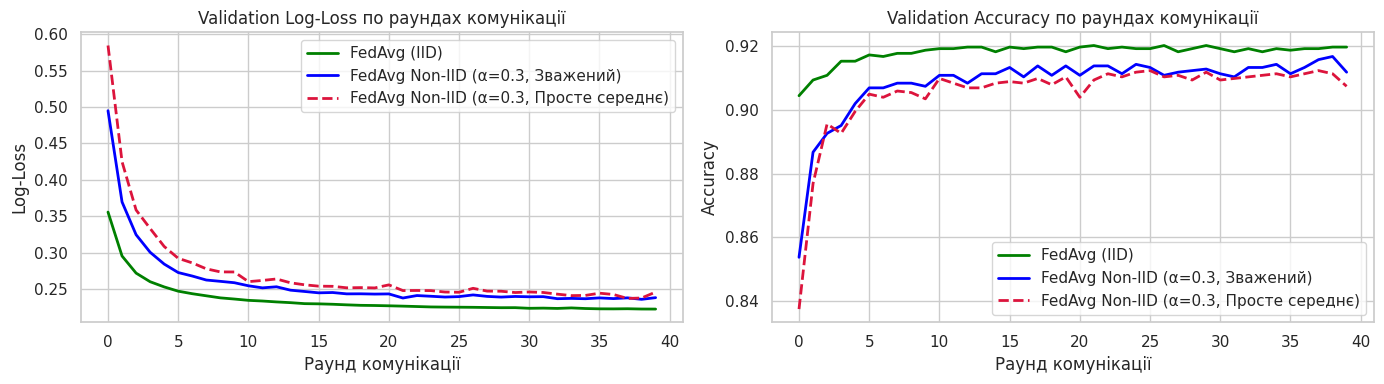

In [23]:
# Порівняльні графіки динамики по комунікаційних раундах
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Графік Loss
axes[0].plot(hist_iid['val_loss'], label='FedAvg (IID)', color='green', lw=2)
axes[0].plot(hist_noniid_w['val_loss'], label='FedAvg Non-IID (α=0.3, Зважений)', color='blue', lw=2)
axes[0].plot(hist_noniid_unw['val_loss'], label='FedAvg Non-IID (α=0.3, Просте середнє)', color='crimson', linestyle='--', lw=2)
axes[0].set_title("Validation Log-Loss по раундах комунікації")
axes[0].set_xlabel("Раунд комунікації")
axes[0].set_ylabel("Log-Loss")
axes[0].legend()

# Графік Accuracy
axes[1].plot(hist_iid['val_acc'], label='FedAvg (IID)', color='green', lw=2)
axes[1].plot(hist_noniid_w['val_acc'], label='FedAvg Non-IID (α=0.3, Зважений)', color='blue', lw=2)
axes[1].plot(hist_noniid_unw['val_acc'], label='FedAvg Non-IID (α=0.3, Просте середнє)', color='crimson', linestyle='--', lw=2)
axes[1].set_title("Validation Accuracy по раундах комунікації")
axes[1].set_xlabel("Раунд комунікації")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

На IID loss падає швидко й плавно. На Non-IID старт гірший, далі loss виходить на плато ≈ 0.24, а accuracy трохи «стрибає» (±0.3 п.п.), бо кожне усереднення тягне модель у різні боки. 40 раундів вистачає для збіжності.

In [24]:
# ==============================================================================
# 8. ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ (ЛОКАЛЬНІ VS FEDAVG VS ЦЕНТРАЛІЗОВАНА)
# ==============================================================================

def evaluate_local_models(partition, X_pool, Y_pool, X_test, y_test_idx, n_cls=7):
    """
    Навчання незалежних локальних моделей тільки на даних конкретного клієнта.
    Тестування кожної на Global Test.
    """
    local_metrics_list = []
    for k, idxs in partition.items():
        X_k, Y_k = X_pool[idxs], Y_pool[idxs]
        model_k = SoftmaxRegression(n_features=N_FEATURES, n_classes=n_cls, lambda_reg=1e-4, seed=SEED + k)
        model_k.fit(X_k, Y_k, learning_rate=0.2, epochs=40, batch_size=32, verbose=False)
        
        p_test = model_k.predict_proba(X_test)
        pred_test = np.argmax(p_test, axis=1)
        m = compute_metrics(y_test_idx, pred_test, p_test, n_cls=n_cls)
        local_metrics_list.append(m)
        
    # Усереднені показники локальних моделей
    avg_acc = np.mean([m['accuracy'] for m in local_metrics_list]) * 100
    avg_bal_acc = np.mean([m['balanced_acc'] for m in local_metrics_list]) * 100
    avg_f1 = np.mean([m['macro_f1'] for m in local_metrics_list]) * 100
    avg_loss = np.mean([m['log_loss'] for m in local_metrics_list])
    
    return avg_acc, avg_bal_acc, avg_f1, avg_loss

# Оцінюємо локальні моделі для IID та Non-IID (alpha=0.3)
iid_loc_acc, iid_loc_bal, iid_loc_f1, iid_loc_loss = evaluate_local_models(
    partitions['IID'], X_train_pool, Y_train_pool, X_test, y_test_idx
)
noniid_loc_acc, noniid_loc_bal, noniid_loc_f1, noniid_loc_loss = evaluate_local_models(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool, X_test, y_test_idx
)

# Зведена таблиця
df_three_models = pd.DataFrame([
    {'Сценарій': 'Централізований бейзлайн', 'Тип моделі': 'Централізована (усі дані)', 
     'Accuracy (%)': test_metrics['accuracy']*100, 'Balanced Acc (%)': test_metrics['balanced_acc']*100, 
     'Macro-F1 (%)': test_metrics['macro_f1']*100, 'Log-Loss': test_metrics['log_loss']},
    
    {'Сценарій': 'IID розподіл', 'Тип моделі': 'Локальні моделі (середнє)', 
     'Accuracy (%)': iid_loc_acc, 'Balanced Acc (%)': iid_loc_bal, 
     'Macro-F1 (%)': iid_loc_f1, 'Log-Loss': iid_loc_loss},
    {'Сценарій': 'IID розподіл', 'Тип моделі': 'FedAvg (Глобальна)', 
     'Accuracy (%)': test_iid['accuracy']*100, 'Balanced Acc (%)': test_iid['balanced_acc']*100, 
     'Macro-F1 (%)': test_iid['macro_f1']*100, 'Log-Loss': test_iid['log_loss']},
     
    {'Сценарій': 'Non-IID (α=0.3)', 'Тип моделі': 'Локальні моделі (середнє)', 
     'Accuracy (%)': noniid_loc_acc, 'Balanced Acc (%)': noniid_loc_bal, 
     'Macro-F1 (%)': noniid_loc_f1, 'Log-Loss': noniid_loc_loss},
    {'Сценарій': 'Non-IID (α=0.3)', 'Тип моделі': 'FedAvg (Глобальна)', 
     'Accuracy (%)': test_noniid_w['accuracy']*100, 'Balanced Acc (%)': test_noniid_w['balanced_acc']*100, 
     'Macro-F1 (%)': test_noniid_w['macro_f1']*100, 'Log-Loss': test_noniid_w['log_loss']},
])

print("\n--- ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ НА GLOBAL TEST ---")
display(df_three_models.round(2))


--- ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ НА GLOBAL TEST ---


,Сценарій,Тип моделі,Accuracy (%),Balanced Acc (%),Macro-F1 (%),Log-Loss
0,Централізований бейзлайн,Централізована (усі дані),91.98,93.23,93.23,0.22
1,IID розподіл,Локальні моделі (середнє),91.63,92.91,92.98,0.23
2,IID розподіл,FedAvg (Глобальна),92.03,93.36,93.37,0.22
3,Non-IID (α=0.3),Локальні моделі (середнє),70.47,72.26,66.33,1.74
4,Non-IID (α=0.3),FedAvg (Глобальна),91.14,92.28,92.53,0.24


На IID навіть локальні моделі непогані (91.63%), бо клієнту вистачає даних. На Non-IID локальні моделі падають до 70.5% (macro-F1 66.3%), бо клієнт не знає частини класів, а FedAvg тримає 91.14%. Тобто головна користь федеративного навчання проявляється на Non-IID і в збереженні приватності; на IID якість майже така сама.

In [25]:

# ==============================================================================
# 9. ЕКСПЕРИМЕНТАЛЬНІ ДОСЛІДЖЕННЯ
# ==============================================================================
SEEDS = [42, 100, 2024]
BASE_ACC, BASE_F1 = test_metrics['accuracy']*100, test_metrics['macro_f1']*100   # централізований бейзлайн

def run_fl(part, seed, E=3, rounds=30, weighted=True, batch_size=32, lr=0.2, lam=1e-4):
    """Запуск FedAvg на готовому розбитті; повертає (history, test_metrics)."""
    _, h, tm = train_fedavg(part, X_train_pool, Y_train_pool, X_val, Y_val, y_val_idx,
                            X_test, Y_test, y_test_idx, rounds=rounds, local_epochs=E,
                            batch_size=batch_size, lr=lr, lambda_reg=lam, weighted=weighted, seed=seed)
    return h, tm

def make_partition(kind, seed, K=5, alpha=0.3):
    if kind == 'iid':
        return create_iid_partitions(y_train_pool_idx, n_clients=K, seed=seed)
    return create_non_iid_dirichlet(y_train_pool_idx, n_clients=K, alpha=alpha, seed=seed)

def fmt(arr, d=2):
    return f"{np.mean(arr):.{d}f} ± {np.std(arr):.{d}f}"


Централізований бейзлайн: Accuracy = 91.98%, Macro-F1 = 93.23%


,Сценарій,Accuracy (%),Macro-F1 (%),Balanced Acc (%),Log-Loss,Середній drift,min n_k
0,IID,92.11 ± 0.08,93.46 ± 0.10,93.45 ± 0.10,0.224 ± 0.000,0.631,1894
1,α=5,92.11 ± 0.08,93.46 ± 0.08,93.46 ± 0.08,0.224 ± 0.000,0.791,1515
2,α=1,91.98 ± 0.18,93.35 ± 0.11,93.37 ± 0.12,0.229 ± 0.002,1.160,838
3,α=0.3,91.45 ± 0.19,92.85 ± 0.20,92.71 ± 0.26,0.237 ± 0.002,1.599,413
4,α=0.1,90.21 ± 0.83,91.21 ± 1.27,91.15 ± 0.84,0.284 ± 0.017,1.935,514


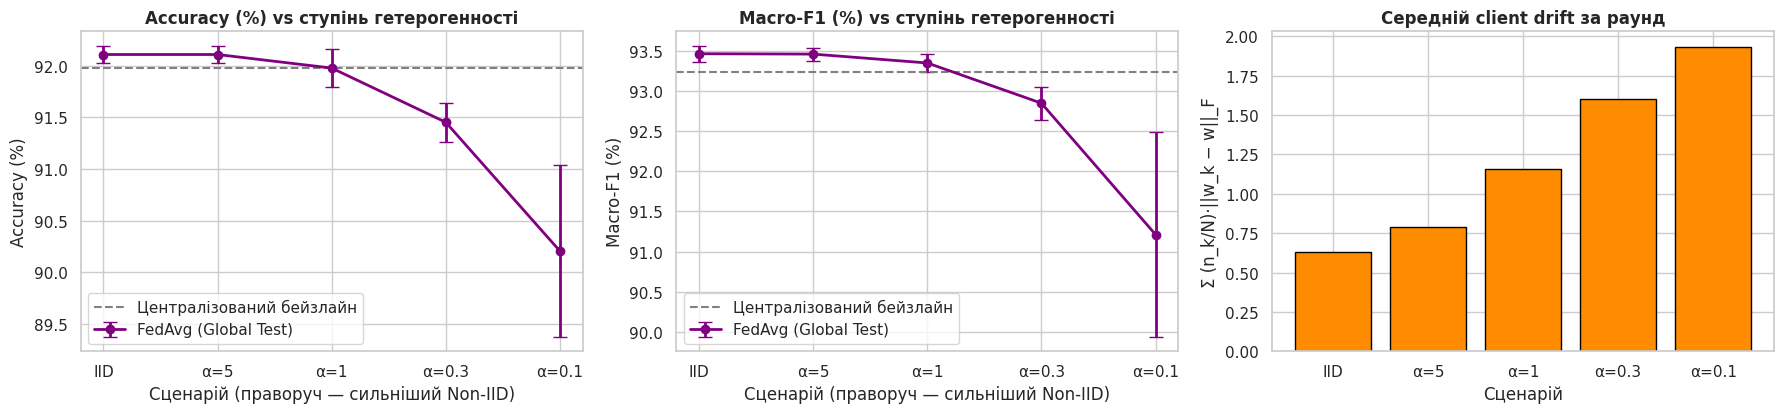

In [26]:

# ------------------------------------------------------------------------------
# ЕКСПЕРИМЕНТ 1. Вплив неоднорідності даних (α), K=5, E=3, 30 раундів, 3 сиди
# (сид змінює і розбиття клієнтів, і ініціалізацію моделі)
# ------------------------------------------------------------------------------
scen1 = [('IID', 'iid', None), ('α=5', 'dir', 5.0), ('α=1', 'dir', 1.0), ('α=0.3', 'dir', 0.3), ('α=0.1', 'dir', 0.1)]
exp1 = {}
for label, kind, a in scen1:
    rec = {'acc': [], 'f1': [], 'bal': [], 'loss': [], 'drift': [], 'min_nk': []}
    for s in SEEDS:
        part = make_partition(kind, s, K=5, alpha=a)
        h, tm = run_fl(part, s)
        rec['acc'].append(tm['accuracy']*100); rec['f1'].append(tm['macro_f1']*100)
        rec['bal'].append(tm['balanced_acc']*100); rec['loss'].append(tm['log_loss'])
        rec['drift'].append(np.mean(h['drift'])); rec['min_nk'].append(min(len(v) for v in part.values()))
    exp1[label] = rec

df_exp1 = pd.DataFrame([{
    'Сценарій': lbl, 'Accuracy (%)': fmt(r['acc']), 'Macro-F1 (%)': fmt(r['f1']), 'Balanced Acc (%)': fmt(r['bal']),
    'Log-Loss': fmt(r['loss'], 3), 'Середній drift': f"{np.mean(r['drift']):.3f}", 'min n_k': int(np.min(r['min_nk']))
} for lbl, r in exp1.items()])
print(f"Централізований бейзлайн: Accuracy = {BASE_ACC:.2f}%, Macro-F1 = {BASE_F1:.2f}%")
display(df_exp1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
labels1 = list(exp1)
for ax, key, ttl, base in zip(axes[:2], ['acc', 'f1'], ['Accuracy (%)', 'Macro-F1 (%)'], [BASE_ACC, BASE_F1]):
    ax.errorbar(labels1, [np.mean(exp1[l][key]) for l in labels1], yerr=[np.std(exp1[l][key]) for l in labels1],
                fmt='-o', color='purple', capsize=5, lw=2, label='FedAvg (Global Test)')
    ax.axhline(base, color='gray', ls='--', label='Централізований бейзлайн')
    ax.set_title(f"{ttl} vs ступінь гетерогенності", fontsize=12, fontweight='bold')
    ax.set_xlabel("Сценарій (праворуч — сильніший Non-IID)"); ax.set_ylabel(ttl); ax.legend()
axes[2].bar(labels1, [np.mean(exp1[l]['drift']) for l in labels1], color='darkorange', edgecolor='black')
axes[2].set_title("Середній client drift за раунд", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Сценарій"); axes[2].set_ylabel("Σ (n_k/N)·||w_k − w||_F")
plt.tight_layout(); plt.show()


Чим різноманітніші клієнти, тим трохи гірший результат: IID і α = 5 дають 92.11%, α = 1 — 91.98%, α = 0.3 — 91.45%, α = 0.1 — 90.21%. Розкид між запусками росте (з 0.08 до 0.83), а drift (наскільки локальні моделі розходяться з глобальною) зростає з 0.63 до 1.94. Причина в тому, що в кожного клієнта свій оптимум, і їхнє середнє не збігається з загальним. Падіння невелике (≈ 0.5 п.п. при α = 0.3), бо модель проста, а клієнти великі. Глобальна модель справді може бути гіршою за централізовану (при α ≤ 0.3), але вона набагато краща за локальні.

,Сценарій,E,Accuracy (%),Macro-F1 (%),Фінальний val-loss,Drift (раунд 1 → останній)
0,"(а) K=5, α=0.3",1,91.29 ± 0.00,92.72 ± 0.15,0.2480,3.185 → 0.936
1,"(а) K=5, α=0.3",5,91.45 ± 0.17,92.86 ± 0.25,0.2387,5.299 → 1.625
2,"(а) K=5, α=0.3",10,91.09 ± 0.18,92.56 ± 0.15,0.2409,6.388 → 2.005
3,"(а) K=5, α=0.3",20,90.86 ± 0.37,92.37 ± 0.19,0.2449,7.539 → 2.464
4,"(б) K=10, α=0.1",1,91.16 ± 0.08,92.39 ± 0.05,0.2825,2.656 → 0.850
5,"(б) K=10, α=0.1",5,90.62 ± 0.57,91.80 ± 0.64,0.2765,4.164 → 1.539
6,"(б) K=10, α=0.1",10,89.88 ± 1.11,91.16 ± 1.06,0.2911,4.946 → 1.943
7,"(б) K=10, α=0.1",20,89.09 ± 1.18,90.44 ± 1.04,0.3086,5.793 → 2.441


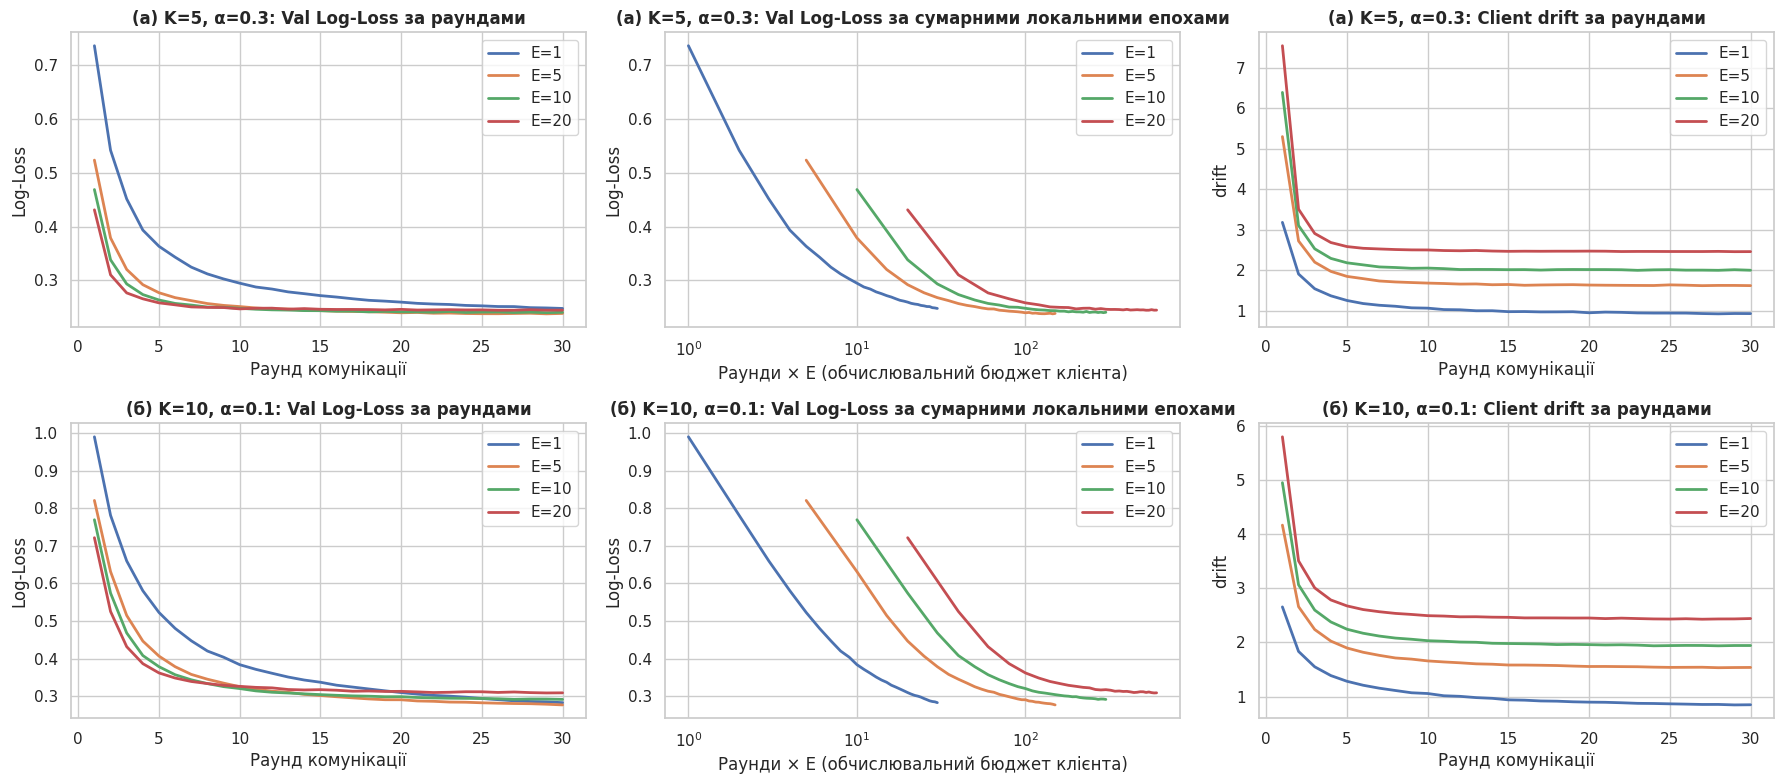

In [27]:

# ------------------------------------------------------------------------------
# ЕКСПЕРИМЕНТ 2. Вплив кількості локальних епох E та client drift
#   (а) завданням задано:  K=5,  α=0.3
#   (б) посилений сценарій: K=10, α=0.1  (щоб drift був краще видно)
# Для кожного сида — своє розбиття. Криві усереднені по 3 сидах.
# ------------------------------------------------------------------------------
E_LIST = [1, 5, 10, 20]      # E = 1, 5, 10 — за завданням, E = 20 — додатково
ROUNDS2 = 30
scen2 = {'(а) K=5, α=0.3': dict(K=5, alpha=0.3), '(б) K=10, α=0.1': dict(K=10, alpha=0.1)}
exp2 = {}
rows2 = []
for sc_name, cfg in scen2.items():
    for E in E_LIST:
        curves, drifts, accs, f1s = [], [], [], []
        for s in SEEDS:
            part = make_partition('dir', s, K=cfg['K'], alpha=cfg['alpha'])
            h, tm = run_fl(part, s, E=E, rounds=ROUNDS2)
            curves.append(h['val_loss']); drifts.append(h['drift'])
            accs.append(tm['accuracy']*100); f1s.append(tm['macro_f1']*100)
        exp2[(sc_name, E)] = {'loss': np.mean(curves, axis=0), 'drift': np.mean(drifts, axis=0)}
        rows2.append({'Сценарій': sc_name, 'E': E, 'Accuracy (%)': fmt(accs), 'Macro-F1 (%)': fmt(f1s),
                      'Фінальний val-loss': f"{exp2[(sc_name, E)]['loss'][-1]:.4f}",
                      'Drift (раунд 1 → останній)': f"{exp2[(sc_name, E)]['drift'][0]:.3f} → {exp2[(sc_name, E)]['drift'][-1]:.3f}"})
display(pd.DataFrame(rows2))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for r_i, sc_name in enumerate(scen2):
    for E in E_LIST:
        d = exp2[(sc_name, E)]
        axes[r_i, 0].plot(range(1, ROUNDS2+1), d['loss'], lw=2, label=f'E={E}')
        axes[r_i, 1].plot(np.arange(1, ROUNDS2+1) * E, d['loss'], lw=2, label=f'E={E}')
        axes[r_i, 2].plot(range(1, ROUNDS2+1), d['drift'], lw=2, label=f'E={E}')
    axes[r_i, 0].set_title(f"{sc_name}: Val Log-Loss за раундами", fontweight='bold'); axes[r_i, 0].set_xlabel("Раунд комунікації")
    axes[r_i, 1].set_title(f"{sc_name}: Val Log-Loss за сумарними локальними епохами", fontweight='bold'); axes[r_i, 1].set_xlabel("Раунди × E (обчислювальний бюджет клієнта)")
    axes[r_i, 1].set_xscale('log')
    axes[r_i, 2].set_title(f"{sc_name}: Client drift за раундами", fontweight='bold'); axes[r_i, 2].set_xlabel("Раунд комунікації")
    for c in range(3): axes[r_i, c].legend()
    axes[r_i, 0].set_ylabel("Log-Loss"); axes[r_i, 1].set_ylabel("Log-Loss"); axes[r_i, 2].set_ylabel("drift")
plt.tight_layout(); plt.show()


Client drift — це коли за кілька локальних епох клієнт надто віддаляється від глобальної моделі, бо оптимізує лише свої дані. Чим більше E, тим більший drift (у сценарії (а) від 0.94 до 2.46 при E від 1 до 20). У (а) K = 5, α = 0.3 різниця мала: найкраще E = 5 (91.45%), при E = 20 — 90.86%. У складнішому (б) K = 10, α = 0.1 видно чітко: 91.16% → 89.09%. Більше E прискорює перші раунди, але у складному Non-IID кінцева якість гірша, тому беремо E ≈ 5.

Dirichlet α=0.3 (розміри ≈ рівні): розміри клієнтів (сид 42) = [1048, 1314, 1505, 1537, 4076]


Quantity skew (α=0.3, β=0.3): розміри клієнтів (сид 42) = [25, 1877, 1882, 2541, 3155]


,Сценарій,Агрегація,Accuracy (%),Macro-F1 (%),Balanced Acc (%),Log-Loss
0,Dirichlet α=0.3 (розміри ≈ рівні),зважена n_k/N,91.45 ± 0.19,92.85 ± 0.20,92.71 ± 0.26,0.237 ± 0.002
1,Dirichlet α=0.3 (розміри ≈ рівні),просте середнє 1/K,91.49 ± 0.24,92.97 ± 0.10,92.84 ± 0.06,0.245 ± 0.007
2,"Quantity skew (α=0.3, β=0.3)",зважена n_k/N,91.31 ± 0.52,92.66 ± 0.49,92.40 ± 0.48,0.258 ± 0.014
3,"Quantity skew (α=0.3, β=0.3)",просте середнє 1/K,91.60 ± 0.24,92.89 ± 0.27,92.84 ± 0.12,0.247 ± 0.002


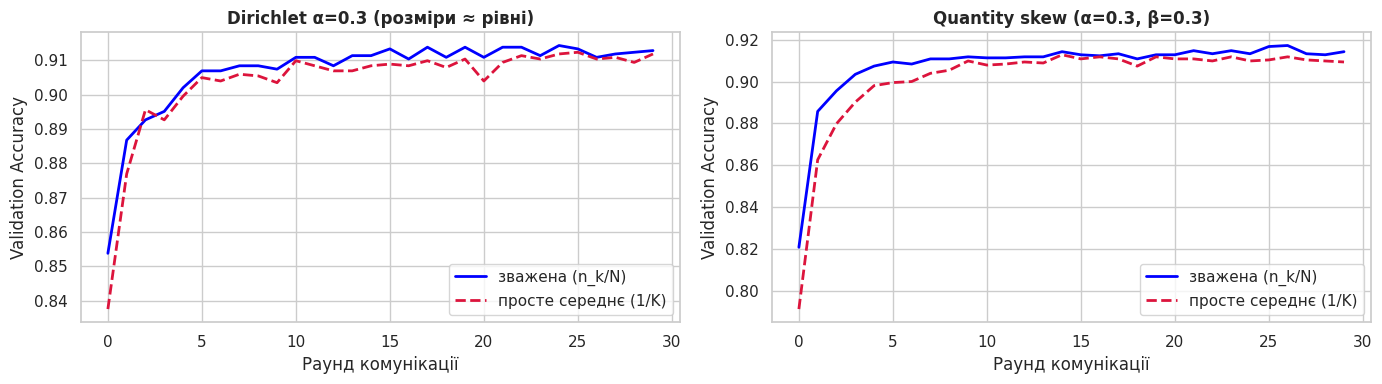

In [28]:

# ------------------------------------------------------------------------------
# ЕКСПЕРИМЕНТ 3 (до питань 10–11). Чи потрібне зважування за n_k?
# У стандартному Dirichlet-розбитті клієнти приблизно однакові за розміром (min n_k ~ 10³),
# тому зважування майже не відрізняється від простого середнього. Щоб перевірити це
# чесно, додатково створюємо розбиття з НЕРІВНИМИ обсягами (quantity skew):
#   частка клієнта k від класу c  ∝  Dir(α)_k · s_k,   s ~ Dir(β)  — розмір клієнта.
# ------------------------------------------------------------------------------
def create_quantity_label_skew(y_indices, n_clients=5, alpha=0.3, beta=0.3, min_size=10, seed=42, max_retries=500):
    for attempt in range(max_retries):
        rr = np.random.default_rng(seed + attempt * 100)
        size_w = rr.dirichlet(np.repeat(beta, n_clients))
        client_indices = {k: [] for k in range(n_clients)}
        for c in np.unique(y_indices):
            idxs = np.where(y_indices == c)[0]; rr.shuffle(idxs)
            p = rr.dirichlet(np.repeat(alpha, n_clients)) * size_w
            p = p / p.sum()
            cuts = (np.cumsum(p) * len(idxs)).astype(int)[:-1]
            for k, chunk in enumerate(np.split(idxs, cuts)):
                client_indices[k].extend(chunk)
        if min(len(v) for v in client_indices.values()) >= min_size:
            return {k: rr.permutation(np.array(v)) for k, v in client_indices.items()}
    raise RuntimeError("Не вдалося згенерувати розбиття з quantity skew")

rows3, curves3 = [], {}
scen3 = {'Dirichlet α=0.3 (розміри ≈ рівні)': lambda s: make_partition('dir', s, K=5, alpha=0.3),
         'Quantity skew (α=0.3, β=0.3)':       lambda s: create_quantity_label_skew(y_train_pool_idx, 5, 0.3, 0.3, seed=s)}
for sc_name, maker in scen3.items():
    for weighted in [True, False]:
        accs, f1s, bals, losses = [], [], [], []
        for s in SEEDS:
            part = maker(s)
            h, tm = run_fl(part, s, weighted=weighted)
            accs.append(tm['accuracy']*100); f1s.append(tm['macro_f1']*100); bals.append(tm['balanced_acc']*100); losses.append(tm['log_loss'])
            if s == SEEDS[0]: curves3[(sc_name, weighted)] = h['val_acc']; sizes_demo = sorted(len(v) for v in part.values())
        rows3.append({'Сценарій': sc_name, 'Агрегація': 'зважена n_k/N' if weighted else 'просте середнє 1/K',
                      'Accuracy (%)': fmt(accs), 'Macro-F1 (%)': fmt(f1s), 'Balanced Acc (%)': fmt(bals), 'Log-Loss': fmt(losses, 3)})
        if weighted: print(f"{sc_name}: розміри клієнтів (сид {SEEDS[0]}) = {sizes_demo}")
display(pd.DataFrame(rows3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sc_name in zip(axes, scen3):
    ax.plot(curves3[(sc_name, True)], lw=2, label='зважена (n_k/N)', color='blue')
    ax.plot(curves3[(sc_name, False)], lw=2, ls='--', label='просте середнє (1/K)', color='crimson')
    ax.set_title(sc_name, fontweight='bold'); ax.set_xlabel("Раунд комунікації"); ax.set_ylabel("Validation Accuracy"); ax.legend()
plt.tight_layout(); plt.show()


Зважування за кількістю даних теоретично правильне (клієнт із 25 прикладами не має впливати так само, як клієнт із 3 000), але на практиці виграшу не вийшло: при нерівних обсягах зважена дала 91.31 ± 0.52%, проста — 91.60 ± 0.24%, а у звичайному Dirichlet результат однаковий. Причина в тому, що модель проста, а надто малий клієнт лише один. Зважування лишаємо, бо воно відповідає постановці FedAvg, а не тому, що дало кращий результат.

## Додаткові експерименти (етап 7)
Виконано обидва: **А** (вплив кількості клієнтів) та **Б** (персоналізація).

,Розподіл,K,Accuracy (%),Macro-F1 (%),min n_k,Середній drift
0,IID,3,92.03 ± 0.04,93.35 ± 0.02,3159,0.68
1,IID,5,92.11 ± 0.08,93.46 ± 0.10,1894,0.63
2,IID,10,92.06 ± 0.02,93.31 ± 0.02,945,0.55
3,Non-IID α=0.3,3,91.21 ± 0.30,92.69 ± 0.17,406,1.87
4,Non-IID α=0.3,5,91.45 ± 0.19,92.85 ± 0.20,413,1.60
5,Non-IID α=0.3,10,91.63 ± 0.22,92.95 ± 0.11,74,1.20


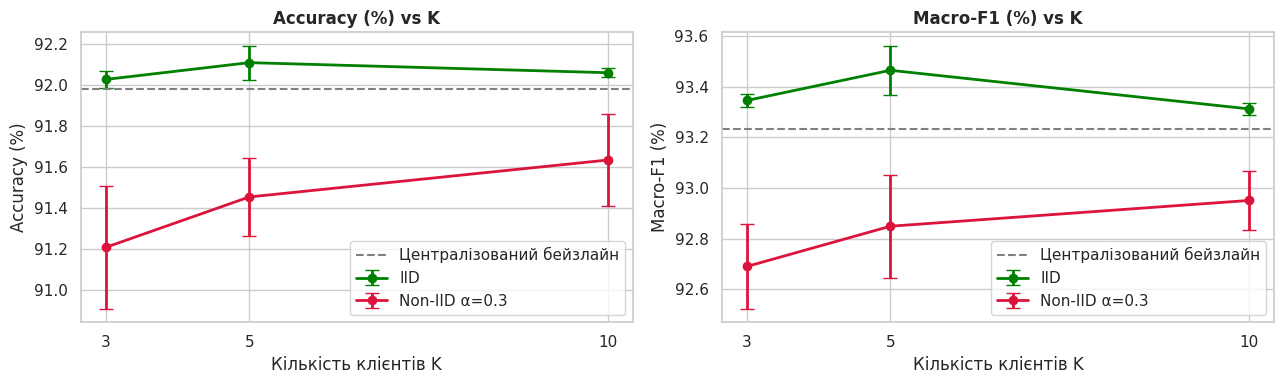

In [29]:

# ------------------------------------------------------------------------------
# ДОДАТКОВИЙ ЕКСПЕРИМЕНТ А. Вплив кількості клієнтів K ∈ {3, 5, 10}
# (пул даних той самий, тож зі збільшенням K кожен клієнт має менше даних)
# ------------------------------------------------------------------------------
KS = [3, 5, 10]
expA, rowsA = {}, []
for label, kind, a in [('IID', 'iid', None), ('Non-IID α=0.3', 'dir', 0.3)]:
    for K in KS:
        accs, f1s, nk_min, drs = [], [], [], []
        for s in SEEDS:
            part = make_partition(kind, s, K=K, alpha=a)
            h, tm = run_fl(part, s)
            accs.append(tm['accuracy']*100); f1s.append(tm['macro_f1']*100); nk_min.append(min(len(v) for v in part.values())); drs.append(np.mean(h['drift']))
        expA[(label, K)] = (np.mean(accs), np.std(accs), np.mean(f1s), np.std(f1s))
        rowsA.append({'Розподіл': label, 'K': K, 'Accuracy (%)': fmt(accs), 'Macro-F1 (%)': fmt(f1s), 'min n_k': int(np.min(nk_min)), 'Середній drift': f"{np.mean(drs):.2f}"})
display(pd.DataFrame(rowsA))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (idx, ttl, base) in zip(axes, [(0, 'Accuracy (%)', BASE_ACC), (2, 'Macro-F1 (%)', BASE_F1)]):
    for label, col in [('IID', 'green'), ('Non-IID α=0.3', 'crimson')]:
        ax.errorbar(KS, [expA[(label, K)][idx] for K in KS], yerr=[expA[(label, K)][idx+1] for K in KS],
                    fmt='-o', capsize=5, lw=2, color=col, label=label)
    ax.axhline(base, color='gray', ls='--', label='Централізований бейзлайн')
    ax.set_xticks(KS); ax.set_xlabel("Кількість клієнтів K"); ax.set_ylabel(ttl)
    ax.set_title(f"{ttl} vs K", fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()


В IID кількість клієнтів майже не впливає (≈ 92.0–92.1%). У Non-IID якість навіть трохи зростає: 91.21% → 91.45% → 91.63%, а drift падає (1.87 → 1.20). Пояснення: у кожного клієнта менше даних, отже менше локальних кроків, і моделі менше розходяться. Це стосується нашого випадку; із ще меншими клієнтами (при K = 10 найменший має 74 приклади) очікувано буде гірше.

Клієнти для сида 42 (локальні тести):


,Клієнт,n_local_test,Global acc,Global loss,Global GT acc,Pers(E=1) acc,Pers(E=1) loss,Pers(E=1) GT acc,Pers(E=2) acc,Pers(E=2) loss,Pers(E=2) GT acc,Local-only acc,Local-only loss,Local-only GT acc
0,1,301,94.35,0.20,91.29,95.02,0.16,91.44,95.02,0.14,91.58,97.67,0.06,66.24
1,2,307,92.18,0.37,91.29,93.49,0.31,90.80,94.14,0.29,90.26,95.11,0.22,65.55
2,3,262,87.40,0.34,91.29,92.37,0.22,91.93,93.51,0.20,91.78,96.56,0.14,83.51
3,4,209,92.34,0.22,91.29,97.13,0.15,90.35,98.09,0.11,89.47,98.56,0.05,47.34
4,5,815,92.39,0.21,91.29,93.87,0.19,90.80,93.74,0.18,90.31,93.74,0.18,87.65


,"Accuracy на локальному тесті (%), mean ± std по клієнтах і сидах",Log-Loss,Accuracy на Global Test (%)
Глобальна FedAvg,91.63 ± 2.02,0.235 ± 0.057,91.37 ± 0.08
Персоналізована (+1 епоха),94.70 ± 1.88,0.176 ± 0.053,90.95 ± 0.82
Персоналізована (+2 епохи),95.27 ± 1.93,0.156 ± 0.055,89.91 ± 1.80
Лише локальна,96.40 ± 2.09,0.120 ± 0.063,68.46 ± 11.75


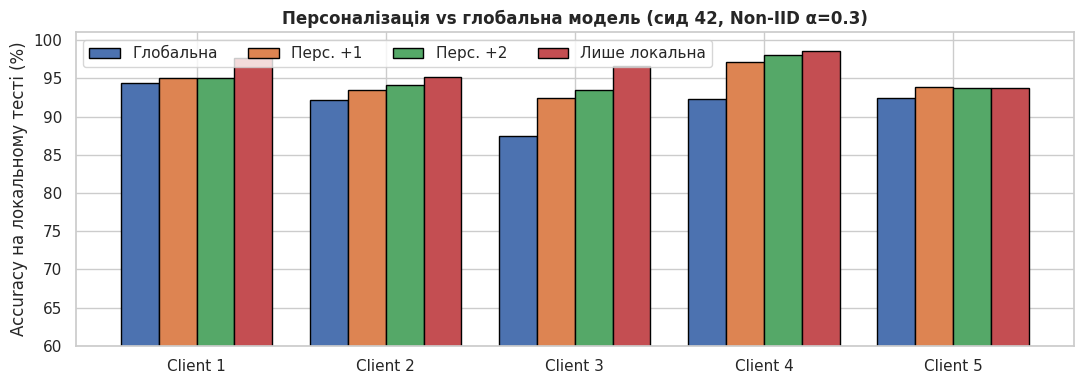

In [30]:

# ------------------------------------------------------------------------------
# ДОДАТКОВИЙ ЕКСПЕРИМЕНТ Б. Персоналізація: глобальна модель + донавчання 1–2 епохи
# Кожен клієнт ділить D_k на локальний train (80%) та локальний test (20%).
# FedAvg навчається ЛИШЕ на локальних train; порівняння — на локальних test клієнтів.
# Non-IID α=0.3, K=5, E=3, 30 раундів, 3 сиди.
# ------------------------------------------------------------------------------
def split_local(part, test_frac=0.2, seed=0):
    rr = np.random.default_rng(seed)
    tr, te = {}, {}
    for k, idxs in part.items():
        idxs = rr.permutation(idxs); n_te = max(1, int(len(idxs) * test_frac))
        te[k], tr[k] = idxs[:n_te], idxs[n_te:]
    return tr, te

def eval_gt(model):
    return np.mean(model.predict(X_test) == y_test_idx) * 100   # Global Test — лише для оцінки ціни персоналізації

def eval_local(model, idxs):
    p = model.predict_proba(X_train_pool[idxs])
    yt = y_train_pool_idx[idxs]
    return np.mean(p.argmax(1) == yt) * 100, -np.mean(np.log(np.clip(p[np.arange(len(yt)), yt], 1e-12, 1.0)))

rowsB = []
for s in SEEDS:
    part = make_partition('dir', s, K=5, alpha=0.3)
    tr, te = split_local(part, seed=s)
    g_model, _, _ = train_fedavg(tr, X_train_pool, Y_train_pool, X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
                                 rounds=30, local_epochs=3, batch_size=32, lr=0.2, lambda_reg=1e-4, seed=s)
    for k in range(5):
        acc_g, ll_g = eval_local(g_model, te[k])
        row = {'Сид': s, 'Клієнт': k+1, 'n_local_test': len(te[k]), 'Global acc': acc_g, 'Global loss': ll_g, 'Global GT acc': eval_gt(g_model)}
        for Ep in [1, 2]:
            pm = SoftmaxRegression(N_FEATURES, num_classes, lambda_reg=1e-4, seed=s + k)
            pm.W, pm.b = g_model.W.copy(), g_model.b.copy()
            pm.fit(X_train_pool[tr[k]], Y_train_pool[tr[k]], learning_rate=0.05, epochs=Ep, batch_size=32)
            row[f'Pers(E={Ep}) acc'], row[f'Pers(E={Ep}) loss'] = eval_local(pm, te[k]); row[f'Pers(E={Ep}) GT acc'] = eval_gt(pm)
        lm = SoftmaxRegression(N_FEATURES, num_classes, lambda_reg=1e-4, seed=s + k)
        lm.fit(X_train_pool[tr[k]], Y_train_pool[tr[k]], learning_rate=0.2, epochs=40, batch_size=32)
        row['Local-only acc'], row['Local-only loss'] = eval_local(lm, te[k]); row['Local-only GT acc'] = eval_gt(lm)
        rowsB.append(row)

df_B = pd.DataFrame(rowsB)
print("Клієнти для сида 42 (локальні тести):")
display(df_B[df_B['Сид'] == 42].drop(columns='Сид').round(2))

cols_acc = ['Global acc', 'Pers(E=1) acc', 'Pers(E=2) acc', 'Local-only acc']
cols_loss = ['Global loss', 'Pers(E=1) loss', 'Pers(E=2) loss', 'Local-only loss']
summ = pd.DataFrame({'Accuracy на локальному тесті (%), mean ± std по клієнтах і сидах': [fmt(df_B[c]) for c in cols_acc],
                     'Log-Loss': [fmt(df_B[c], 3) for c in cols_loss],
                     'Accuracy на Global Test (%)': [fmt(df_B[c]) for c in ['Global GT acc', 'Pers(E=1) GT acc', 'Pers(E=2) GT acc', 'Local-only GT acc']]},
                    index=['Глобальна FedAvg', 'Персоналізована (+1 епоха)', 'Персоналізована (+2 епохи)', 'Лише локальна'])
display(summ)

fig, ax = plt.subplots(figsize=(11, 4))
w = 0.2; xs = np.arange(5)
for i, (c, lbl) in enumerate(zip(cols_acc, ['Глобальна', 'Перс. +1', 'Перс. +2', 'Лише локальна'])):
    ax.bar(xs + (i - 1.5)*w, df_B[df_B['Сид'] == 42][c].values, w, label=lbl, edgecolor='black')
ax.set_xticks(xs); ax.set_xticklabels([f"Client {k+1}" for k in range(5)]); ax.set_ylim(60, 101)
ax.set_ylabel("Accuracy на локальному тесті (%)"); ax.set_title("Персоналізація vs глобальна модель (сид 42, Non-IID α=0.3)", fontweight='bold'); ax.legend(ncol=4)
plt.tight_layout(); plt.show()


Якщо глобальну модель донавчити 1–2 епохи на своїх даних, точність на локальному тесті зростає з 91.63% до 95.27% (у клієнта 3 — з 87.4% до 93.5%). Суто локальна модель локально ще краща (96.40%), але на глобальному тесті має лише 68.46%. Ціна донавчання невелика: на глобальному тесті 91.37% → 89.91% (після двох епох). Тож персоналізація корисна, коли важливий саме свій розподіл, але робити її краще короткою.

# 10. Відповіді на теоретичні питання

1. **Призначення Softmax та чисельна стабільність:**
   Функція Softmax перетворює вектор довільних дійсних чисел (логітів) $z$ у ймовірнісний розподіл: $P(y=c) = \frac{e^{z_c}}{\sum_j e^{z_j}}$, де $\sum_c P_c = 1$. При великих додатних значеннях $z$ операція $e^z$ викликає переповнення (overflow, `inf`). Для забезпечення числової стабільності від кожного логіта віднімають максимум рядка: $\tilde{z} = z - \max(z)$. Математично це еквівалентно множенню чисельника і знаменника на константу $e^{-\max(z)}$, що запобігає переповненню без спотворення результату.

2. **Cross-Entropy Loss та інтуїція градієнта:**
   Формула: $L = -\frac{1}{m} \sum_{i} \sum_{c} y_{ic} \ln(p_{ic})$. Вона мінімізує відстань Кульбака-Лейблера між істинним та передбаченим розподілами. Градієнт $\frac{\partial L}{\partial Z} = P - Y$ має інтуїтивний зміст помилки передбачення: це вектор нев'язки між змодельованою ймовірністю та бінарним індикатором істинного класу.

3. **Ridge ($\ell_2$) проти Lasso ($\ell_1$):**
   $\ell_2$-регуляризація ($\frac{\lambda}{2} \Vert{}W\Vert{}_2^2$) пропорційно зменшує абсолютні значення всіх коефіцієнтів (weight decay), згладжуючи ваги при мультиколінеарності. $\ell_1$-регуляризація ($\lambda \Vert{}W\Vert{}_1$) має кутасті ізоповерхні, що призводить до занулення частини ваг і слугує вбудованим відбором ознак (feature selection).

4. **Чому bias ($b$) не регуляризують:**
   Зсув $b$ визначає апріорну ймовірність класів незалежно від ознак $X$. Штрафування $b$ штучно зміщує межу розділення до початку координат і погіршує налаштування на природний дисбаланс класів.

5. **Сутність Data Leakage:**
   Data Leakage (витік даних) — це потрапляння інформації з валідаційної або тестової вибірки в процес навчання чи попередньої обробки. Це створює ілюзію високої точності на розробці, яка обвалюється у продакшені.

   *У цій роботі:* дублікати видалено до розбиття; скейлер, кореляції, VIF, η² та відбір ознак — лише на Train Pool; Global Validation — для гіперпараметрів і відбору ознак; Global Test — лише фінальна оцінка.
6. **Чому тестова вибірка не використовується для вибору гіперпараметрів:**
   Багаторазова оптимізація параметрів за результатами тесту перетворює тестовий набір на частину навчального процесу. Це призводить до перенавчання під конкретний тестовий зріз і втрати об'єктивної оцінки узагальнення.

7. **Чому StandardScaler налаштовується лише на Train:**
   Параметри $\mu$ та $\sigma$ оцінюють розподіл генеральної сукупності на основі доступних навчальних спостережень. Залучення тесту є прямим витоком інформації про майбутній розподіл.

   У федеративному варіанті клієнти надсилають серверу лише $(n_k,\mu_k,\sigma_k^2)$; агрегація точна (Δ ≈ 10⁻¹²), Validation/Test у обчисленні не беруть участі.
8. **Що таке Federated Learning (FL) та його переваги:**
   FL — це парадигма машинного навчання, за якої модель навчається децентралізовано на множині кінцевих вузлів (клієнтів) без необхідності централізованого збору їхніх сирих даних. Переваги: збереження приватності, відповідність GDPR, економія мережевого трафіку.

9. **Чому сервер не бачить сирих даних:**
   Клієнти локально виконують обчислення і передають на сервер виключно параметри моделі (ваги $W$ та $b$). Сервер виконує лише агрегацію числових масивів.

10. **Чому потрібне зважування у FedAvg:**
    Клієнти володіють різною кількістю спостережень $n_k$. Зважування $\frac{n_k}{N}$ гарантує, що вклад кожного локального оновлення пропорційний обсягу представлених ним даних, оптимізуючи глобальну цільову функцію: $f(w) = \sum \frac{n_k}{N} f_k(w)$.

11. **Що буде без зважування при Non-IID:**
    Кожен клієнт отримує голос $1/K$ незалежно від $n_k$, тож глобальна модель мінімізує $\sum \frac{1}{K}F_k$ замість $\sum \frac{n_k}{N}F_k$ — зміщену оцінку глобального ризику, де клієнт із 25 прикладів важить стільки ж, скільки клієнт із 3 000. Це робить модель чутливою до шуму малих вузлів. **Проте експеримент 3 цього не підтвердив:** у розбитті з нерівними обсягами проста агрегація дала 91.60 ± 0.24% acc (зважена — 91.31 ± 0.52%), у стандартному Dirichlet різниці немає (мінімальний клієнт там мав 1 048 прикладів, а не «10»). Тобто зважування теоретично правильне, але на лінійній моделі його перевагу показати не вдалося.
12. **Що таке Non-IID розподіл даних:**
    Це ситуація, коли локальні дані клієнтів не є незалежними та однаково розподіленими ($P_k(X, Y) \neq P_j(X, Y)$). Це може виражатися у формі зміщення міток (label distribution skew), зміщення ознак чи концептуального зсуву.

13. **Чому якість FL погіршується на Non-IID даних:**
    Локальні градієнти клієнтів вказують у різні сторони, бо мінімізують власні $F_k$, що не збігаються з глобальною $F$; усереднення $w_k$ зміщене відносно глобального оптимуму. Експеримент 1 (3 сиди): acc 92.11% (α = 5) → 91.98% (1) → 91.45% (0.3) → 90.21% (0.1), std 0.08 → 0.83, виміряний drift 0.63 → 1.94.
14. **Що таке Client Drift (клієнтський зсув):**
    Накопичення розбіжності між локальною моделлю $w_k$ і глобальною моделлю (та глобальним оптимумом) за кілька локальних епох. Вимірюємо $\sum_k \frac{n_k}{N}\|w_k - w\|_F$: на плато він пропорційний $E$ (0.94 → 2.46 при $E$ = 1 → 20) і зростає зі зменшенням α.
15. **Вплив кількості локальних епох $E$:**
    Більше $E$ — менше комунікації й швидший початок навчання (loss після 1-го раунду: 0.43 при $E$ = 20 проти 0.74 при $E$ = 1), але більший drift. У сценарії K = 5, α = 0.3 оптимум $E \approx 5$ (acc 91.45%; при $E$ = 20 — 90.86%); у жорсткішому K = 10, α = 0.1 деградація монотонна: 91.16% → 89.09%.
16. **Чи може глобальна модель FedAvg бути гіршою за централізовану / за локальну:**
    Так. За централізовану — при сильному Non-IID (α = 0.3: −0.5 п.п., α = 0.1: −1.8 п.п. acc; при α ≥ 1 різниці немає). За локальні — на Global Test ні (локальні 70.5% у Non-IID), але на *локальних* тестах клієнтів локальна модель краща (96.4% проти 91.6%, експеримент Б) — тому існує персоналізація.
17. **Чому Macro-F1 та Balanced Accuracy важливіші за Accuracy:**
    При наявності дисбалансу (наприклад, класс Bombay становить менше 4%) звичайний Accuracy може залишатися на рівні 90%+, навіть якщо міноритарний клас повністю ігнорується моделлю. Macro-F1 та Balanced Accuracy надають усім класам однакової ваги, об'єктивно показуючи якість розпізнавання рідкісних класів.

# 11. Загальний висновок

1. Дані чисті, але ознаки сильно дублюють одна одну: 15 із 16 мають VIF > 10. Скорочення набору ознак нічого не дало (однаковий macro-F1), тому залишили всі 16. Модель працює правильно: перевірка градієнта показала похибку 5·10⁻¹⁰.

2. Центральна модель має 92% точності. Помиляється вона найчастіше між DERMASON і SIRA, бо вони схожі за розміром. BOMBAY розпізнає ідеально.

3. Чим різноманітніші дані у клієнтів, тим трохи гірший результат. Чим більше локальних епох, тим сильніше моделі «розбігаються», але помітно це лише у складному сценарії. Зважування за кількістю даних теоретично правильне, але на практиці виграшу не дало.